# ⛰️ Predicción de Accidentes en Federados de Deportes de Montaña

## Proyecto de Machine Learning

### Equipo  
* Arrate Alducin Arrilucea  
* Danilo Castillo  
* Ricardo Díaz Coca  

---

## Índice

1. Exploración de los datos (EDA)  
2. Preparación y preprocesamiento de datos  
3. Modelado  
4. Evaluación de modelos  
5. Interpretación del modelo  
6. Conclusiones  

---

## Introducción

Los deportes de montaña implican un nivel inherente de riesgo debido a factores como las condiciones ambientales, la dificultad técnica de las rutas y la experiencia de los participantes. En este contexto, analizar los patrones asociados a los accidentes puede ayudar a comprender mejor qué factores influyen en el riesgo dentro de la población federada.

En este proyecto se desarrolla un modelo de **Machine Learning** con el objetivo de analizar y estimar la probabilidad de accidentes entre federados de deportes de montaña a partir de la información disponible en el dataset.

El problema se plantea como un **problema de clasificación binaria**, donde el objetivo del modelo es predecir si un federado **sufrirá un accidente (1)** o **no sufrirá un accidente (0)** durante el periodo analizado.

El análisis se basa en variables como la **edad**, el **historial de accidentes**, la **modalidad de federación** y ciertas **características demográficas**. Dado que los accidentes representan una proporción relativamente pequeña del total de observaciones, el problema presenta un **fuerte desbalance entre clases**, lo que requiere el uso de métricas de evaluación adecuadas y técnicas específicas durante el proceso de modelado.

A lo largo del proyecto se exploran distintos modelos de clasificación, incluyendo **Logistic Regression, Random Forest y XGBoost**, comparando su rendimiento y optimizando sus hiperparámetros mediante técnicas de **validación cruzada**. Además, se analizan los factores que más influyen en la predicción a través de la interpretación de los coeficientes del modelo final y el cálculo de **odds ratios**, lo que permite entender mejor la influencia de cada variable en la probabilidad de accidente.

---

## Objetivos del proyecto

- Analizar los patrones asociados a los accidentes en federados de deportes de montaña  
- Construir y comparar distintos modelos de clasificación para estimar la probabilidad de accidente  
- Optimizar los modelos mediante **tuning de hiperparámetros** y validación cruzada  
- Interpretar los resultados del modelo final para identificar los factores más influyentes en el riesgo de accidente  

---

# 1. Exploración de los datos (EDA)

En esta sección se realiza un análisis exploratorio del dataset para comprender su estructura, distribución de variables y posibles relaciones entre ellas.

---

# 2. Preparación y preprocesamiento de datos

Aquí se realizan las transformaciones necesarias para preparar los datos para el modelado, incluyendo limpieza de datos, selección de variables y codificación de variables categóricas.

---

# 3. Modelado

En esta sección se entrenan distintos modelos de clasificación para predecir la probabilidad de accidente. Se comparan diferentes algoritmos y se analizan sus resultados iniciales.

---

# 4. Evaluación de modelos

Se evalúa el rendimiento de los modelos utilizando métricas adecuadas para datasets desbalanceados, como **ROC AUC** y **Precision-Recall AUC**.

---

# 5. Interpretación del modelo

Se analizan los coeficientes del modelo final y se calculan los **odds ratios** para entender cómo influyen las distintas variables en la probabilidad de accidente.

---

# 6. Conclusiones

En esta sección se resumen los principales resultados del proyecto, destacando las capacidades y limitaciones del modelo desarrollado.

---

## Configuración del entorno y librerías

En esta sección se importan las librerías necesarias para el análisis de datos, el desarrollo de los modelos de Machine Learning y la visualización de resultados.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración de visualización
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

## Carga de los datos

En esta sección se carga el dataset que se utilizará para el análisis y el desarrollo de los modelos de Machine Learning.

In [2]:
df = pd.read_csv("/Users/radc/Desktop/dataset_definitivo.csv")
df.head()


,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,helicoptero,hospitalizacion,target,accidenteshistoricos,edad,temporada_federado,Actividad,Lugar,Provincia,TipoAccidente,DescripcionGrado,TamañoGrupo,NResponsables,Entrenamiento,ActividadPersonal,ActividadOrganizada,Festivo,año_accidente
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,89,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,90,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,88,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,80,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,81,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Inspección inicial del dataset

Antes de comenzar el análisis exploratorio, se realiza una primera inspección del dataset para entender su estructura, las variables disponibles y los tipos de datos presentes.

In [3]:
df.info()
print("=" * 50)
print("\nColumnas del dataset:\n")
print(df.columns)
print("=" * 50)
print("\nTipos de datos:\n")
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 121276 entries, 0 to 121275
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   nsocio                 121276 non-null  int64  
 1   codigopostaldomicilio  121276 non-null  str    
 2   numeroclub             121276 non-null  str    
 3   modalidad              121276 non-null  str    
 4   categoria              121276 non-null  str    
 5   discapacidad           121276 non-null  str    
 6   numeroaccidentesaño    121276 non-null  float64
 7   helicoptero            121276 non-null  float64
 8   hospitalizacion        121276 non-null  float64
 9   target                 121276 non-null  int64  
 10  accidenteshistoricos   121276 non-null  float64
 11  edad                   121276 non-null  int64  
 12  temporada_federado     121276 non-null  int64  
 13  Actividad              17900 non-null   str    
 14  Lugar                  17373 non-null   str    

---

### Comprobación de duplicados por socio

Dado que `nsocio` identifica a cada federado, es importante comprobar si existen múltiples registros asociados al mismo socio dentro del dataset. Esto permite entender si el dataset contiene varias observaciones por persona.

In [4]:
df["nsocio"].duplicated().sum()

np.int64(84317)

In [5]:
df.groupby("nsocio")["temporada_federado"].nunique().describe()

count    36959.000000
mean         3.165372
std          1.967821
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          6.000000
Name: temporada_federado, dtype: float64

Este resultado indica cuántos registros corresponden a socios que aparecen más de una vez en el dataset.

---

### Resumen estructural del dataset

Para facilitar la exploración del dataset, se define una función que resume información relevante de cada variable, incluyendo:

- tipo de dato (numérico o categórico)
- porcentaje de valores nulos
- número de valores únicos
- cardinalidad relativa de cada variable

Esto permite identificar rápidamente posibles problemas como valores faltantes, variables con alta cardinalidad o columnas que requieren tratamiento especial.

In [6]:
def describe_df(df):
    
    data_dict = {}
    
    for columna in df.columns:
        data_type = "categorica" if df[columna].dtype == "object" else "numerica"
        
        valores_nulos = round(df[columna].isna().sum() / len(df) * 100, 1)
        
        valores_unicos = df[columna].nunique()
        
        cardinalidad_ptg = round(valores_unicos / len(df) * 100, 2)
        
        data_dict[columna] = {
            "data_type": data_type,
            "valores_nulos": valores_nulos,
            "valores_unicos": valores_unicos,
            "cardinalidad_ptg": cardinalidad_ptg
        }
    
    return pd.DataFrame(data_dict).T

In [7]:
describe_df(df)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
nsocio,numerica,0.0,36959,30.48
codigopostaldomicilio,numerica,0.0,1635,1.35
numeroclub,numerica,0.0,181,0.15
modalidad,numerica,0.0,15,0.01
categoria,numerica,0.0,10,0.01
discapacidad,numerica,0.0,113,0.09
numeroaccidentesaño,numerica,0.0,4,0.0
helicoptero,numerica,0.0,1,0.0
hospitalizacion,numerica,0.0,2,0.0
target,numerica,0.0,2,0.0


La función `describe_df()` permite obtener un resumen estructural de todas las variables del dataset. A partir de este análisis se observa que las columnas relacionadas con **siniestros** presentan un alto porcentaje de valores nulos, lo cual es consistente con la naturaleza del problema, dado que los accidentes representan una pequeña proporción del total de observaciones.

---

### Creación del dataset para modelado

Para mantener el dataset original intacto durante el análisis, se crea una nueva versión del dataframe denominada `df_model`, que será utilizada en las etapas posteriores de preparación de datos y modelado.

In [8]:
df_model = df.copy()
df_model

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,helicoptero,hospitalizacion,target,accidenteshistoricos,edad,temporada_federado,Actividad,Lugar,Provincia,TipoAccidente,DescripcionGrado,TamañoGrupo,NResponsables,Entrenamiento,ActividadPersonal,ActividadOrganizada,Festivo,año_accidente
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,89,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,90,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,88,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,80,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,81,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121271,78946,28080,07.28.475,AU,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,28,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121272,79253,28045,07.28.370,B,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,34,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121273,78924,28016,07.28.000,C,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,22,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121274,79882,46007,07.28.000,OT,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,29,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

### Eliminación de variables con posible *data leakage*

Nuestro objetivo es predecir si un federado tendrá un **siniestro en el futuro**, por lo que no debemos incluir variables que solo existen cuando el siniestro ya ha ocurrido.

Estas columnas provienen del dataset de siniestros y presentan un alto porcentaje de valores nulos, ya que únicamente contienen información para los federados que han sufrido un accidente.

Si el modelo utilizara estas variables, podría aprender a predecir el *target* simplemente detectando la presencia o ausencia de estos valores, lo que produciría **data leakage**.

Por este motivo, estas columnas se eliminan antes de entrenar el modelo.

In [9]:
drop_cols = [
    "Actividad",
    "Lugar",
    "Provincia",
    "TipoAccidente",
    "DescripcionGrado",
    "TamañoGrupo",
    "NResponsables",
    "Entrenamiento",
    "ActividadPersonal",
    "ActividadOrganizada",
    "Festivo",
    "año_accidente",
    "hospitalizacion",
    "helicoptero"
]

---

In [10]:
df_model = df.drop(columns=drop_cols) 

A continuación se revisa la estructura del nuevo dataset para comprobar que las columnas restantes son adecuadas para continuar con el análisis.

A partir de este punto, el análisis se realiza sobre df_model

In [11]:
df_model.head() 

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0,0.0,89,2020
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0,0.0,90,2021
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0,0.0,88,2020
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,80,2020
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,81,2021


A partir de esta revisión se observa que la columna `categoria` presenta inconsistencias en su formato, como diferencias en el uso de **mayúsculas, tildes y variaciones en la escritura**.

Este tipo de inconsistencias puede generar categorías duplicadas que en realidad representan la misma información, por lo que es necesario **normalizar los valores de esta variable** antes de continuar con el análisis.

---

### Exploración de la variable `categoria`

Para comprender mejor la estructura de la variable `categoria`, revisamos primero sus valores únicos. Esto permite identificar posibles inconsistencias en la escritura, como diferencias en mayúsculas, tildes o variaciones en el formato.

In [12]:
df_model["categoria"].unique()

<StringArray>
[   'Mayor VarÃ³n',     'Mayor Mujer', 'TÃ©cnico VarÃ³n',  'Ãrbitro Mujer',
 'Ãrbitro VarÃ³n',  'TÃ©cnico Mujer',  'Juvenil VarÃ³n',  'Infantil Mujer',
   'Juvenil Mujer', 'Infantil VarÃ³n']
Length: 10, dtype: str

Se observa que la variable presenta inconsistencias en su formato (tildes, mayúsculas y variaciones en la escritura).  
Para evitar que estas diferencias generen categorías duplicadas durante el análisis o el modelado, se procede a normalizar los valores de la columna.

In [13]:
df_model["categoria"] = (
    df_model["categoria"]
    .str.encode("latin1")
    .str.decode("utf-8")
)

In [14]:
df_model["categoria"].unique()

<StringArray>
[   'Mayor Varón',    'Mayor Mujer',  'Técnico Varón',  'Árbitro Mujer',
  'Árbitro Varón',  'Técnico Mujer',  'Juvenil Varón', 'Infantil Mujer',
  'Juvenil Mujer', 'Infantil Varón']
Length: 10, dtype: str

Tras la normalización, las categorías presentan un formato consistente, lo que facilita su análisis y evita duplicidades innecesarias.

---

### Análisis de la edad por categoría

Para entender mejor la estructura de la variable `categoria`, analizamos cómo se distribuye la **edad** dentro de cada categoría.

Este análisis nos permite observar las diferencias entre grupos y comprobar si las categorías corresponden aproximadamente a distintos rangos de edad (por ejemplo: **niños, jóvenes y adultos**). Esta información será útil para definir posteriormente una simplificación de las categorías.

In [15]:
df_model.groupby("categoria")["edad"].describe() 

,count,mean,std,min,25%,50%,75%,max
categoria,,,,,,,,
Infantil Mujer,1904.0,9.649160,2.559398,0.0,8.0,10.0,12.00,13.0
Infantil Varón,2378.0,9.596299,2.663299,0.0,8.0,10.0,12.00,13.0
Juvenil Mujer,737.0,15.362280,1.124258,14.0,14.0,15.0,16.00,18.0
Juvenil Varón,1273.0,15.513747,1.115221,14.0,15.0,16.0,17.00,17.0
Mayor Mujer,36429.0,50.654232,13.489542,18.0,41.0,51.0,61.00,89.0
Mayor Varón,76142.0,51.096648,13.749852,15.0,42.0,51.0,62.00,90.0
Técnico Mujer,201.0,43.114428,10.232392,22.0,37.0,43.0,51.00,66.0
Técnico Varón,2068.0,48.286267,12.086139,19.0,40.0,48.0,56.25,86.0
Árbitro Mujer,45.0,56.044444,6.310005,46.0,52.0,56.0,59.00,71.0


### Simplificación de categorías por edad y sexo

Con el objetivo de reducir la complejidad de la variable `categoria` y mejorar su consistencia, definimos una función que agrupa y simplifica las categorías teniendo en cuenta criterios de **edad** y **sexo**.

Esta transformación permite trabajar con un conjunto de categorías más homogéneo y fácil de interpretar.

In [16]:
def grupo_persona(row): 
    edad = row["edad"]
    cat = row["categoria"]
    
    if "Mujer" in cat:
        sexo = "Mujer"
    else:
        sexo = "Hombre"
    
    if edad < 14:
        return f"Niño/a {sexo}"
    elif edad < 18:
        return f"Juvenil {sexo}"
    else:
        return sexo

A continuación, aplicamos la función definida anteriormente para crear una nueva columna con las **categorías simplificadas**, que será la utilizada en los análisis posteriores y en el modelado.

In [17]:
df_model["grupo_persona"] = df_model.apply(grupo_persona, axis=1)

### Verificación de la variable resultante

Por último, revisamos la nueva columna para comprobar que la simplificación tiene sentido y que las categorías creadas son coherentes con la información original.

In [18]:
df_model["grupo_persona"].value_counts()

grupo_persona
Hombre            78308
Mujer             36676
Niño/a Hombre      2378
Niño/a Mujer       1904
Juvenil Hombre     1274
Juvenil Mujer       736
Name: count, dtype: int64

### Eliminación de la variable original

Una vez creada la nueva variable con las **categorías simplificadas**, la columna original `categoria` deja de ser necesaria para el análisis.

Para evitar redundancias y posibles confusiones en las etapas posteriores del proceso, se elimina la variable original y se mantiene únicamente la versión simplificada.

In [19]:
df_model = df_model.drop(columns="categoria")

Vemos las primeras filas y comprabamos que todo sigue teniendo sentido.

In [20]:
df_model.head(5)

,nsocio,codigopostaldomicilio,numeroclub,modalidad,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,B,NO,0.0,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,B,NO,0.0,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,B,NO,0.0,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,A,NO,0.0,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,A,NO,0.0,0,0.0,81,2021,Mujer


---

# 1. Análisis Exploratorio de los Datos (EDA)

El **Análisis Exploratorio de los Datos (EDA)** tiene como objetivo comprender mejor la estructura del dataset, identificar patrones relevantes y detectar posibles relaciones entre las variables.

En esta sección se analizarán las distribuciones de las principales variables del dataset, así como su relación con la variable objetivo. Este análisis permitirá obtener una primera intuición sobre los factores que pueden estar asociados con la probabilidad de accidente.

### Distribución de la variable objetivo

Antes de analizar las variables explicativas, es importante observar la distribución de la variable objetivo. Esto nos permite entender el grado de desbalance del dataset entre federados que han sufrido un accidente y aquellos que no.

In [21]:
df_model["target"].value_counts() 
df_model["target"].value_counts(normalize=True)

target
0    0.953107
1    0.046893
Name: proportion, dtype: float64

Para complementar esta información, representamos la distribución de la variable objetivo mediante un gráfico que permite visualizar de forma más intuitiva el desbalance entre las clases.

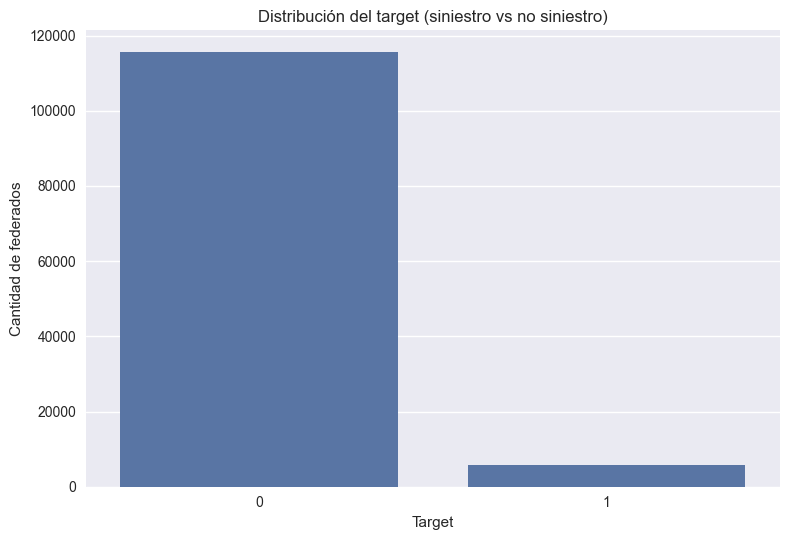

In [22]:
sns.countplot(x="target", data=df_model) 
plt.title("Distribución del target (siniestro vs no siniestro)")
plt.xlabel("Target")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

Para complementar la visualización anterior, representamos la distribución de la variable objetivo mediante un gráfico circular.  
Este tipo de visualización permite apreciar de forma clara la proporción relativa entre federados que han sufrido un accidente y aquellos que no.

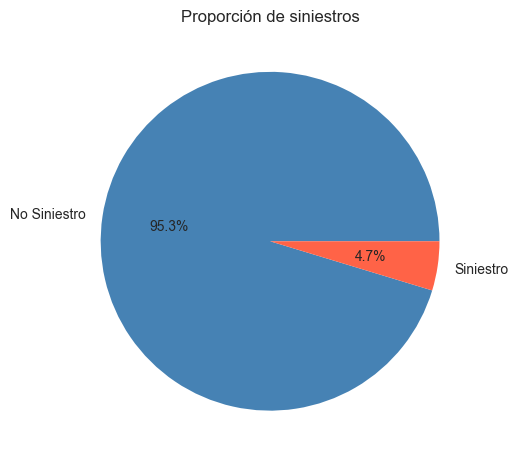

In [23]:
sizes = df_model["target"].value_counts(normalize=True) * 100
plt.pie(sizes, labels=['No Siniestro', 'Siniestro'], autopct='%1.1f%%', 
        colors=['steelblue', 'tomato'])
plt.title('Proporción de siniestros');

El gráfico confirma el **fuerte desbalance del dataset**, donde los accidentes representan una proporción significativamente menor del total de casos.  
Este aspecto deberá tenerse en cuenta durante el proceso de modelado, ya que puede afectar al rendimiento de los modelos de clasificación.

---

### Reorganización del análisis exploratorio

En una versión anterior del proyecto, parte del análisis exploratorio de los datos (EDA) se realizó utilizando el conjunto de entrenamiento (`X_train`) después del *train/test split*.

Para mejorar la claridad del flujo del análisis, en esta versión se ha reorganizado el notebook de forma que el EDA se realice **antes de la partición de los datos**, utilizando `df_model`. De esta manera es posible explorar las relaciones entre variables de forma más natural y comprender mejor la estructura del dataset antes de construir los modelos.

El *train/test split* y las transformaciones de preprocesamiento se realizarán posteriormente mediante un **Pipeline**, lo que garantiza que el preprocesamiento se ajuste únicamente sobre los datos de entrenamiento y evita posibles problemas de *data leakage*.

---

### Análisis de variables categóricas

Tras observar la distribución de la variable objetivo, analizamos las principales variables categóricas del dataset.  
El objetivo es comprender cómo se distribuyen estas variables dentro de la población federada e identificar posibles patrones o diferencias entre categorías.

Este análisis permitirá obtener una primera intuición sobre cómo ciertos grupos o características pueden estar relacionados con la probabilidad de accidente.

In [24]:
categoricas = df_model.select_dtypes(include="object").columns.tolist()

for col in categoricas:
    print(col, df_model[col].nunique())

codigopostaldomicilio 1635
numeroclub 181
modalidad 15
discapacidad 113
grupo_persona 6


/var/folders/0g/ltyf2qv91t9_1979pghhp9fh0000gn/T/ipykernel_9479/3902804838.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df_model.select_dtypes(include="object").columns.tolist()


### Distribución de variables categóricas

A continuación se analiza la distribución de las variables categóricas presentes en el dataset para comprender cómo se reparten los federados entre las distintas categorías.

Sin embargo, algunas de estas variables presentan un número muy elevado de valores únicos (**alta cardinalidad**), lo que dificulta su representación mediante gráficos de frecuencia. Para facilitar la interpretación, se dividirán las variables categóricas en dos grupos:

- **Baja cardinalidad:** variables con menos de 15 categorías únicas, que pueden representarse de forma clara mediante gráficos de frecuencia.
- **Alta cardinalidad:** variables con un número elevado de categorías, cuya visualización directa resultaría poco informativa.

En esta sección se muestran las variables categóricas de **baja cardinalidad**, ya que permiten visualizar de forma clara su distribución. 

Las variables con **alta cardinalidad** también se revisan brevemente, mostrando únicamente un subconjunto de categorías (por ejemplo, las primeras 10) para ilustrar su estructura sin saturar la visualización.

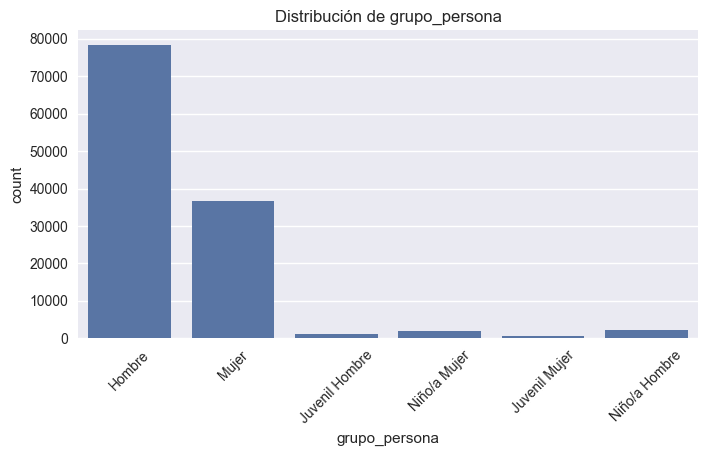

In [25]:
for col in categoricas:
    if df_model[col].nunique() < 15:
        plt.figure(figsize=(8,4))
        sns.countplot(data=df_model, x=col)
        plt.xticks(rotation=45)
        plt.title(f"Distribución de {col}")
        plt.show();

A partir del análisis de cardinalidad, se observa que las variables **`grupo_persona`** y **`modalidad`** presentan un número reducido de categorías, lo que permite visualizar su distribución mediante gráficos de frecuencia.

Por el contrario, variables como **`codigopostaldomicilio`** presentan **alta cardinalidad**, por lo que mostrar todas sus categorías no resultaría informativo. En este caso se muestran únicamente **los códigos postales más frecuentes** para ilustrar su distribución.

La variable **`discapacidad`** no se incluye en las visualizaciones, ya que presenta **muy alta cardinalidad y está compuesta por texto libre no estandarizado**. Esto genera una gran variedad de categorías poco frecuentes, lo que dificulta su interpretación y limita su utilidad en el análisis exploratorio.

Las demás variables categóricas presentan **alta cardinalidad**, es decir, un número elevado de valores únicos. Debido a esto, representar todas las categorías en un gráfico de frecuencia resultaría poco informativo y difícil de interpretar.

Para facilitar la visualización, en estos casos se muestran únicamente **las categorías más frecuentes**, lo que permite obtener una primera aproximación a la distribución de estas variables.

---

A continuación exploramos los valores presentes en la variable `modalidad`, que representa el tipo de licencia o seguro contratado por el federado.

In [26]:
df_model.modalidad.unique()

<StringArray>
[      'B',       'A',      'AU',       'C', 'OTPromo',      'A6',       'D',
 'D Comp.',      'B6',      'OT',       'E',      'B7', 'E Comp.',     'ROC',
 'B Comp.']
Length: 15, dtype: str

Los valores de la variable `modalidad` están codificados mediante letras que representan distintos tipos de licencia o seguro.

Para facilitar la interpretación de los resultados y mejorar la claridad de las visualizaciones, se realiza un mapeo de estas letras a descripciones más informativas que indican el tipo de cobertura de cada modalidad.

In [27]:
df_model_modalidad = df_model.copy()

# Significado de modalidades:

mapeo = {'A': 'Senderismo','A6':'Senderismo España' , 'OT': 'actividades otoño', 'OTPromo': 'actividades otoño',   
         'AU': 'Montaña C.A.Madrid', 'B': 'Montaña', 'B6': 'Montaña', 'B7': 'Montaña', 'B Comp.': 'Montaña competición', 'C': 'Montaña Europa y Marruecos', 
         'ROC': 'Rocodromo',
         'D': 'Montaña < 7000m mundo',                                    
         'D Comp.': 'Montaña < 7000m mundo competición',                                                       
         'E': 'Montaña > 7000m',                                    
         'E Comp.': 'Montaña > 7000m competición'                               
         }

df_model_modalidad["modalidad"] = df_model_modalidad["modalidad"].map(mapeo)

A continuación se muestra la distribución de federados según el tipo de modalidad de licencia.

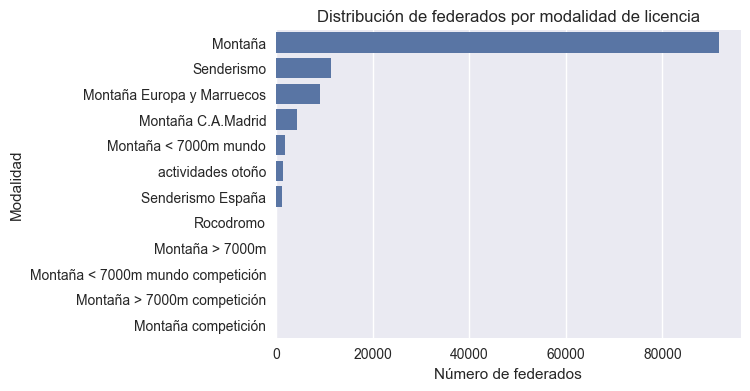

In [28]:
modalidad_counts = df_model_modalidad["modalidad"].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=modalidad_counts.values,
    y=modalidad_counts.index,
    order=modalidad_counts.index
)

plt.title("Distribución de federados por modalidad de licencia")
plt.xlabel("Número de federados")
plt.ylabel("Modalidad")

plt.show();

Observamos que la modalidad **Montaña** concentra la gran mayoría de federados, con cerca de **90.000 licencias**, lo que la convierte claramente en la categoría predominante dentro del dataset.

A bastante distancia se encuentra **Senderismo**, con aproximadamente **10.000 federados**, seguida por modalidades como **Montaña Europa y Marruecos**, con alrededor de **7.000–8.000 federados**, y **Montaña Madrid C.A.**, con cerca de **5.000**.

En general, la distribución muestra una **alta concentración en pocas modalidades**, mientras que el resto de categorías presentan un número significativamente menor de federados.

Esta diferencia en el tamaño de las categorías es importante tenerla en cuenta al analizar posteriormente la proporción de siniestros por modalidad, ya que modalidades con pocos federados pueden presentar mayor variabilidad en sus tasas de accidentes.

---

A continuación se muestra la distribución de las categorías más frecuentes de la variable `codigopostaldomicilio`, como ejemplo representativo de las variables categóricas de alta cardinalidad presentes en el dataset.

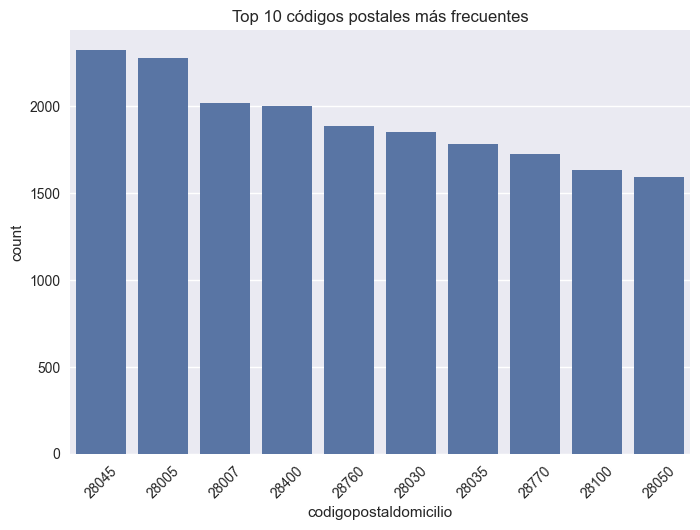

In [29]:
top_n = df_model["codigopostaldomicilio"].value_counts().head(10).index

sns.countplot(
    data=df_model,
    x="codigopostaldomicilio",
    order=top_n
)

plt.title("Top 10 códigos postales más frecuentes")
plt.xticks(rotation=45)
plt.show();

In [30]:
df_model["codigopostaldomicilio"].value_counts().head(10)

codigopostaldomicilio
28045    2322
28005    2278
28007    2020
28400    2002
28760    1884
28030    1853
28035    1779
28770    1725
28100    1633
28050    1592
Name: count, dtype: int64

La variable `codigopostaldomicilio` se ha utilizado como ejemplo de variable categórica de **alta cardinalidad**.  
Otras variables como `numeroclub` o `discapacidad` presentan un comportamiento similar, con un número elevado de categorías.

Debido a esta alta cardinalidad, su representación completa mediante gráficos de frecuencia no resulta especialmente informativa en esta fase del análisis.

---

### Análisis de variables numéricas

A continuación se analiza de forma exploratoria la distribución de las variables numéricas presentes en el dataset.  
Este análisis permite detectar posibles valores extremos, comprender la distribución de las variables y obtener una primera intuición sobre su comportamiento.

Cabe destacar que en etapas posteriores del proyecto algunas de estas variables podrán ser eliminadas tras evaluar su impacto en el rendimiento de los modelos.

In [31]:
numericas = df_model.select_dtypes(include=["int64", "float64"]).columns
numericas

Index(['nsocio', 'numeroaccidentesaño', 'target', 'accidenteshistoricos',
       'edad', 'temporada_federado'],
      dtype='str')

In [32]:
df_model[numericas].describe()

,nsocio,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado
count,121276.000000,121276.000000,121276.000000,121276.000000,121276.000000,121276.000000
mean,46606.696139,0.052558,0.046893,0.135344,48.848527,2022.455927
std,22320.447219,0.249394,0.211411,0.476333,15.918457,1.683185
min,3.000000,0.000000,0.000000,0.000000,0.000000,2020.000000
25%,32506.000000,0.000000,0.000000,0.000000,39.000000,2021.000000
50%,52405.000000,0.000000,0.000000,0.000000,50.000000,2022.000000
75%,63858.250000,0.000000,0.000000,0.000000,61.000000,2024.000000
max,79904.000000,3.000000,1.000000,8.000000,90.000000,2025.000000


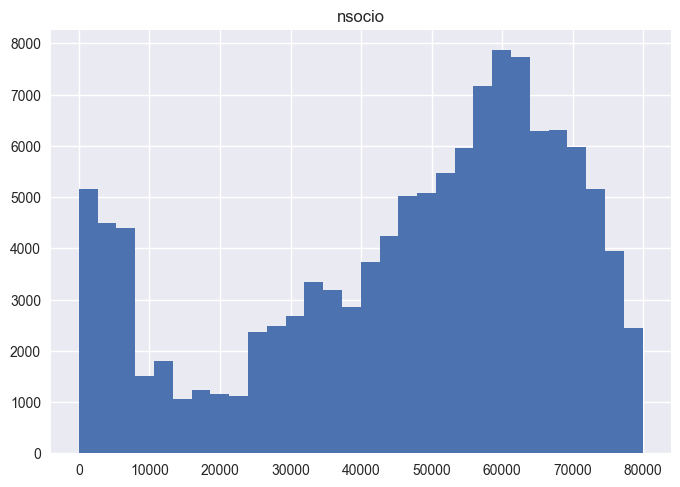

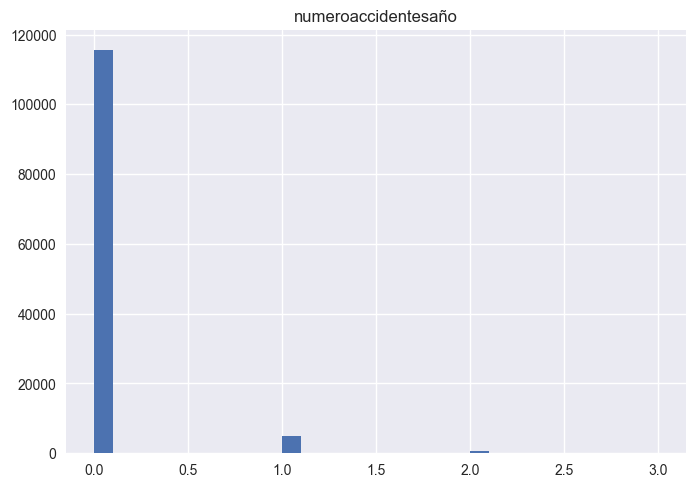

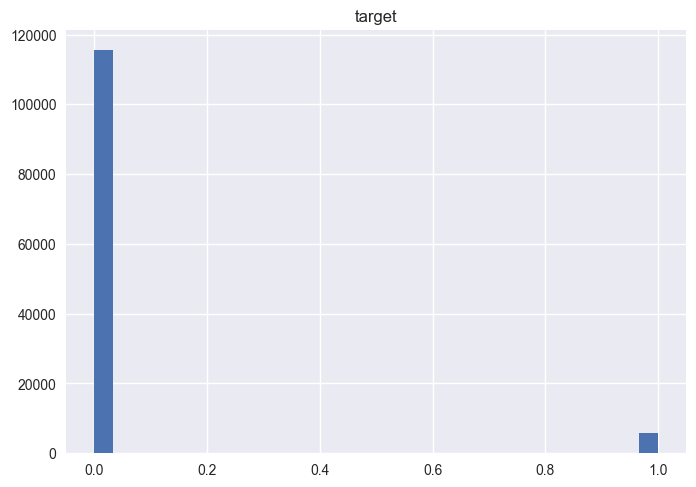

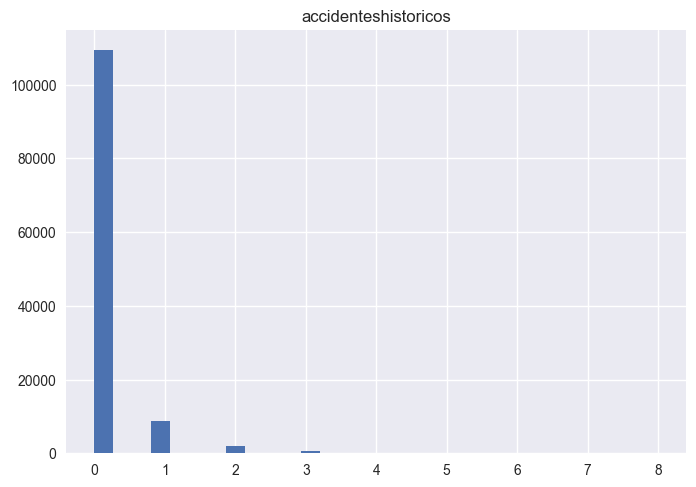

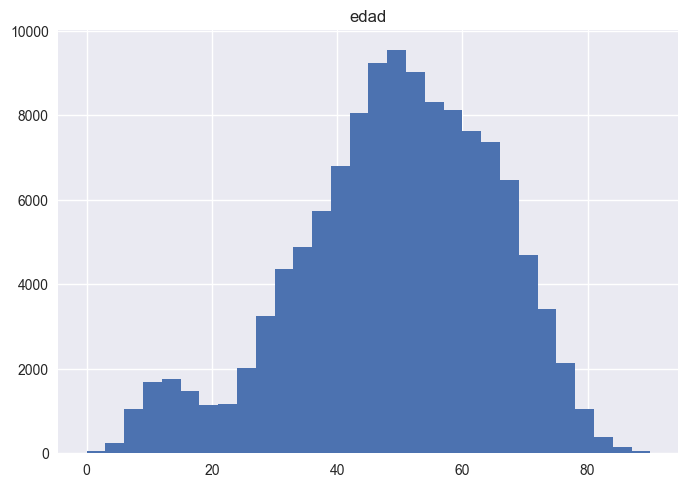

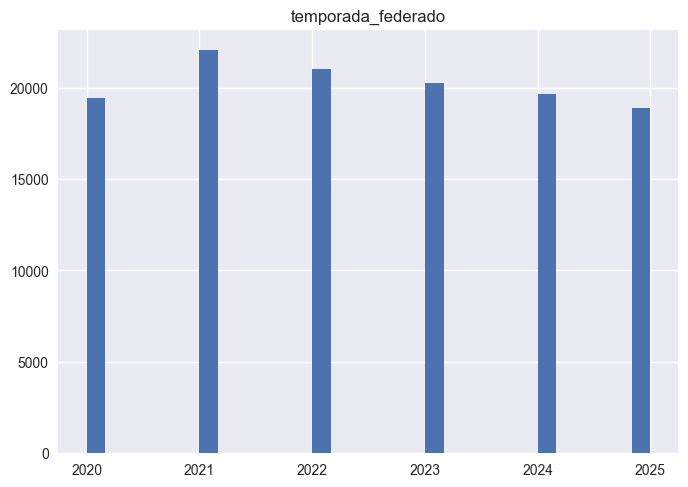

In [33]:
for col in numericas:
    plt.figure()
    df_model[col].hist(bins=30)
    plt.title(col)
    plt.show();

### Interpretación de las variables numéricas

Aunque varias columnas del dataset aparecen representadas como variables numéricas, no todas deben interpretarse como variables continuas.

Por ejemplo, la variable `nsocio` presenta una distribución particular: se observa un **pico inicial**, seguido de una disminución y posteriormente una forma que recuerda a una **curva de campana**. Este comportamiento probablemente está relacionado con la forma en que se asignaron los números de socio a lo largo del tiempo, posiblemente reflejando periodos en los que se registró un mayor número de nuevas federaciones.

Sin embargo, `nsocio` es simplemente un **identificador de socio**, por lo que su valor numérico no contiene información relevante para el análisis predictivo. Por este motivo, aunque se visualice como una variable numérica, **no debe interpretarse como una variable explicativa del modelo**.

De forma similar, otras variables numéricas del dataset representan en realidad **valores discretos u ordinales**, como el número de accidentes registrados o la temporada.

En resumen, dentro de las variables numéricas encontramos distintos tipos:

- **Identificadores:** `nsocio`
- **Variables discretas u ordinales:** `temporada`, número de accidentes
- **Variables binarias:** `target` (0 = no accidente, 1 = accidente)
- **Variables de historial:** `accidenteshistoricos`
- **Variable continua:** `edad`

De todas ellas, **edad es la única variable verdaderamente continua**, por lo que analizaremos primero su distribución y posteriormente su relación con la variable objetivo.

---

### Relación entre variables y la variable objetivo

Una vez analizada la distribución de las variables del dataset, el siguiente paso consiste en explorar cómo se relacionan con la variable objetivo (`target`).

Este análisis permite identificar posibles patrones asociados a la probabilidad de accidente y proporciona una primera intuición sobre qué variables podrían tener mayor capacidad explicativa en el modelo.

Para ello, se analizarán primero las **variables categóricas** y posteriormente las **variables numéricas** en relación con el target.

---

### Relación entre variables categóricas y la variable objetivo

En esta sección se analiza cómo se distribuyen los accidentes dentro de las distintas categorías de cada variable categórica.

Para ello se utilizan **tablas de contingencia (crosstab)**, que permiten observar la proporción de accidentes en cada categoría y detectar posibles diferencias entre grupos.

In [34]:
(pd.crosstab(df_model["grupo_persona"], df_model["target"], normalize="index") * 100).round(2)

target,0,1
grupo_persona,,
Hombre,94.98,5.02
Juvenil Hombre,96.55,3.45
Juvenil Mujer,97.42,2.58
Mujer,95.50,4.50
Niño/a Hombre,99.12,0.88
Niño/a Mujer,99.05,0.95


A partir de estas tablas de contingencia se pueden observar las diferencias en la proporción de accidentes entre las distintas categorías.  
Este tipo de análisis permite identificar posibles patrones en los datos y detectar variables que podrían estar relacionadas con una mayor o menor probabilidad de accidente.

Se observa que la proporción de accidentes es mayor en los grupos adultos (**Hombre y Mujer**), mientras que en los grupos infantiles (**Niño/a**) la incidencia es significativamente menor. Los grupos juveniles presentan valores intermedios, lo que sugiere posibles diferencias de riesgo según la edad o el nivel de actividad.

En las siguientes secciones se analizarán con mayor detalle algunas de estas relaciones, así como el comportamiento de las variables numéricas en relación con la variable objetivo.

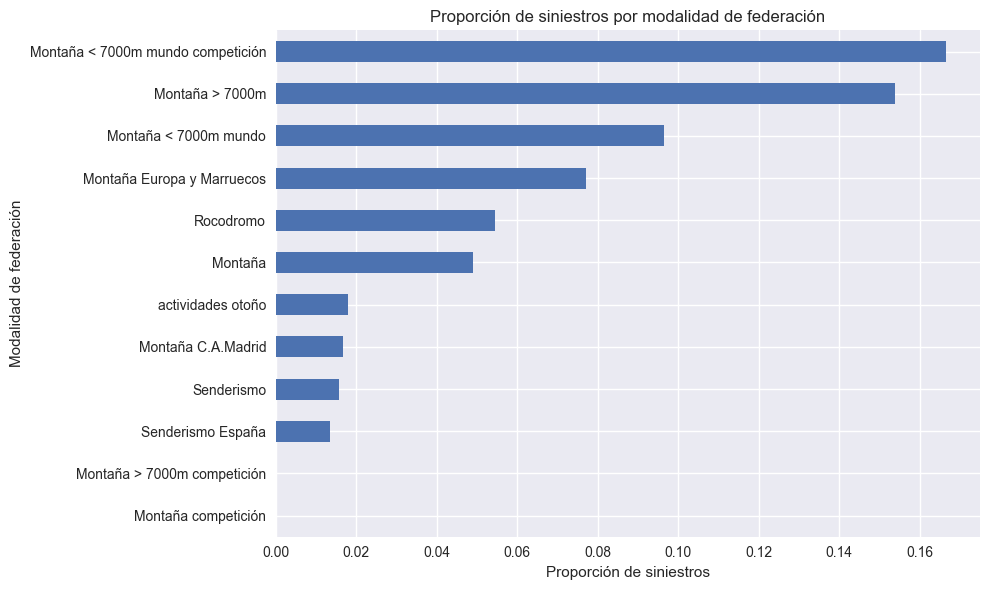

In [35]:
df_model_modalidad.groupby("modalidad")["target"].mean().sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Proporción de siniestros por modalidad de federación")
plt.xlabel("Proporción de siniestros")
plt.ylabel("Modalidad de federación")
plt.tight_layout()
plt.show()

In [36]:
df_model_modalidad.groupby("modalidad")["target"].mean().sort_values()

modalidad
Montaña competición                  0.000000
Montaña > 7000m competición          0.000000
Senderismo España                    0.013333
Senderismo                           0.015629
Montaña C.A.Madrid                   0.016783
actividades otoño                    0.017973
Montaña                              0.048933
Rocodromo                            0.054545
Montaña Europa y Marruecos           0.077090
Montaña < 7000m mundo                0.096527
Montaña > 7000m                      0.153846
Montaña < 7000m mundo competición    0.166667
Name: target, dtype: float64

La proporción de siniestros varía entre modalidades. En general, las modalidades asociadas a actividades de mayor dificultad o ámbito internacional presentan tasas de accidentes más elevadas.

Sin embargo, algunas categorías cuentan con muy pocos federados, por lo que sus proporciones pueden verse afectadas por el reducido número de observaciones.

In [37]:
for col in ["modalidad", "discapacidad", "grupo_persona"]:
    print("\n", col)
    print(pd.crosstab(df_model_modalidad[col], df_model_modalidad["target"], normalize="index"))


 modalidad
target                                    0         1
modalidad                                            
Montaña                            0.951067  0.048933
Montaña < 7000m mundo              0.903473  0.096527
Montaña < 7000m mundo competición  0.833333  0.166667
Montaña > 7000m                    0.846154  0.153846
Montaña > 7000m competición        1.000000  0.000000
Montaña C.A.Madrid                 0.983217  0.016783
Montaña Europa y Marruecos         0.922910  0.077090
Montaña competición                1.000000  0.000000
Rocodromo                          0.945455  0.054545
Senderismo                         0.984371  0.015629
Senderismo España                  0.986667  0.013333
actividades otoño                  0.982027  0.017973

 discapacidad
target                 0         1
discapacidad                      
10% espalda     1.000000  0.000000
14% visual      1.000000  0.000000
15%             1.000000  0.000000
21% Permanente  1.000000  0.000000
33%    

La variable `discapacidad` presenta un número muy elevado de categorías (113 valores distintos), la mayoría de las cuales cuentan con un número muy reducido de observaciones.

Como consecuencia, muchas de estas categorías muestran proporciones extremas (por ejemplo, ausencia total de siniestros), lo que dificulta extraer patrones estadísticamente fiables.

Además, la gran mayoría de los federados pertenecen a la categoría `NO`, lo que limita aún más la capacidad de esta variable para aportar información relevante al modelo.

Debido a su alta cardinalidad y al reducido número de observaciones por categoría, se decide excluir la variable `discapacidad` del modelado posterior.

In [38]:
df_model = df_model_modalidad.copy()
df_model.head()

,nsocio,codigopostaldomicilio,numeroclub,modalidad,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,Montaña,NO,0.0,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,Montaña,NO,0.0,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,Montaña,NO,0.0,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,Senderismo,NO,0.0,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,Senderismo,NO,0.0,0,0.0,81,2021,Mujer


---

### Relación entre variables numéricas y la variable objetivo

A continuación se analiza cómo se comportan las variables numéricas en función de la variable objetivo (`target`). Este análisis permite observar si existen diferencias en la distribución de estas variables entre los federados que han sufrido un accidente y aquellos que no.

Comparar estas distribuciones puede aportar una primera intuición sobre qué variables podrían estar relacionadas con una mayor o menor probabilidad de accidente.

---

### Edad y variable objetivo

Analizamos la distribución de la variable `edad` y su relación con la variable objetivo (`target`), que indica si el federado ha sufrido un accidente (1) o no (0).

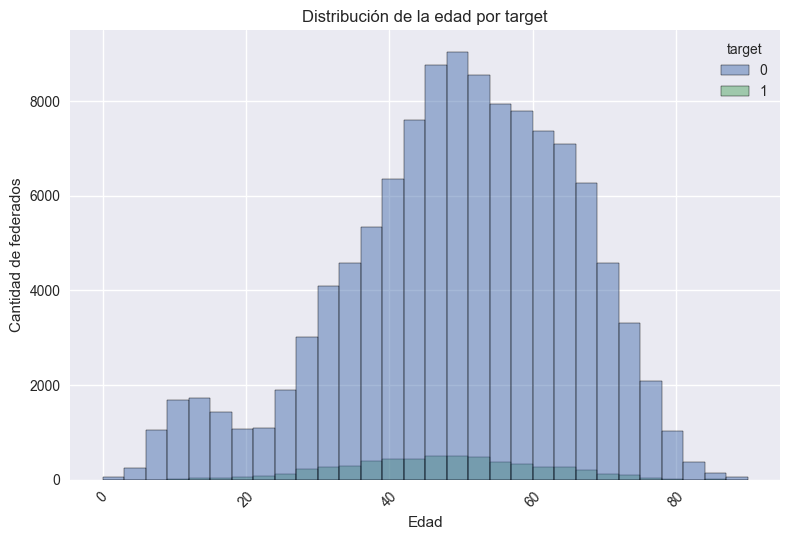

In [39]:
sns.histplot(data=df_model, x="edad", hue="target", bins=30)
plt.xticks(rotation=45)
plt.title("Distribución de la edad por target")
plt.xlabel("Edad")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

La distribución de siniestros por edad parece seguir un patrón similar al de la distribución general de federados.

Esto sugiere que el número de accidentes por edad podría estar influido principalmente por la cantidad de federados presentes en cada grupo de edad, más que por una relación clara entre edad y probabilidad de accidente.

---

### Distribución de edad según la variable objetivo

A continuación analizamos la distribución de la variable `edad` en función del `target` mediante un boxplot, lo que permite comparar la mediana, la dispersión y la presencia de outliers entre federados con y sin accidentes.

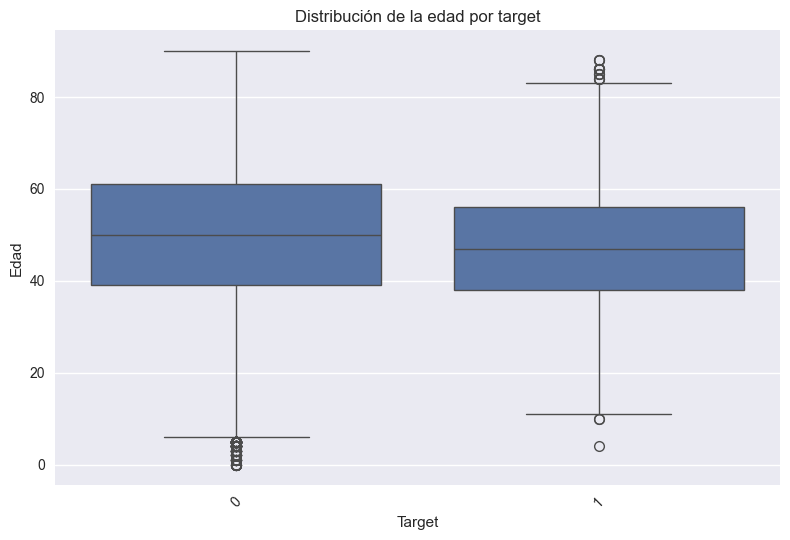

In [40]:
sns.boxplot(x="target", y="edad", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución de la edad por target")
plt.xlabel("Target")
plt.ylabel("Edad")
plt.tight_layout()
plt.show();

Para `target = 0`, el 50% central de las edades se sitúa aproximadamente entre 40 y 60 años, con algunos outliers en edades más bajas.  

En el caso de `target = 1`, el rango intercuartílico se concentra aproximadamente entre 40 y 55 años, mientras que los outliers aparecen principalmente en edades más altas.

Las distribuciones presentan un alto grado de solapamiento, por lo que la edad no parece ser un factor claramente diferenciador entre federados con y sin accidentes.

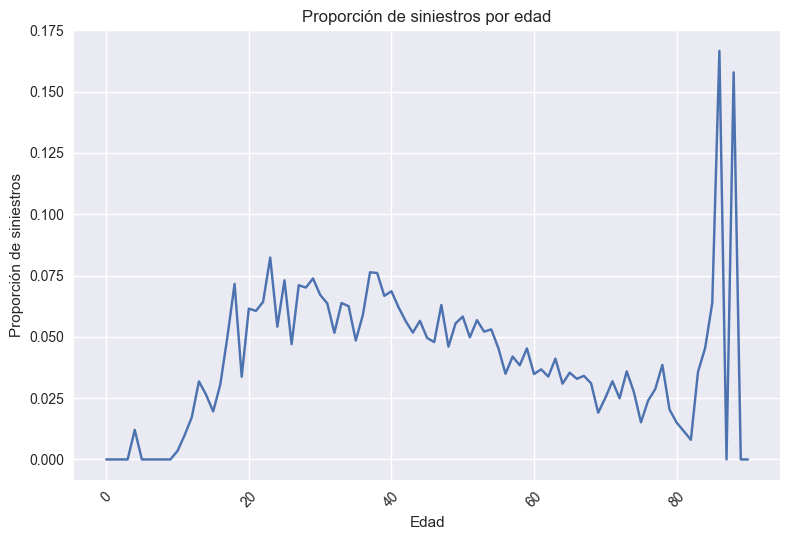

In [41]:
df_model.groupby("edad")["target"].mean().plot()
plt.xticks(rotation=45)
plt.title("Proporción de siniestros por edad")
plt.xlabel("Edad")
plt.ylabel("Proporción de siniestros")
plt.tight_layout()
plt.show();

La proporción media de siniestros aumenta desde la adolescencia hasta alcanzar un pico en torno a los 20 años, tras lo cual tiende a disminuir progresivamente con la edad.

En los extremos del rango de edad se observan picos más pronunciados, especialmente en edades avanzadas, probablemente debido al menor número de federados en estos grupos, lo que aumenta la variabilidad de la proporción observada.

Las edades más tempranas presentan una proporción muy baja de accidentes, lo cual resulta coherente con una menor exposición a actividades de mayor riesgo.

---

### Número de federados por edad

Para contextualizar los resultados anteriores, analizamos también la distribución del número de federados por edad.

Esto permite entender si algunos patrones observados en la proporción de siniestros pueden estar influenciados por el tamaño de cada grupo de edad.

In [42]:
g = df.groupby("edad")["target"].agg(["mean","count"])

g.head()

,mean,count
edad,,
0,0.000000,12
1,0.000000,20
2,0.000000,23
3,0.000000,32
4,0.012048,83


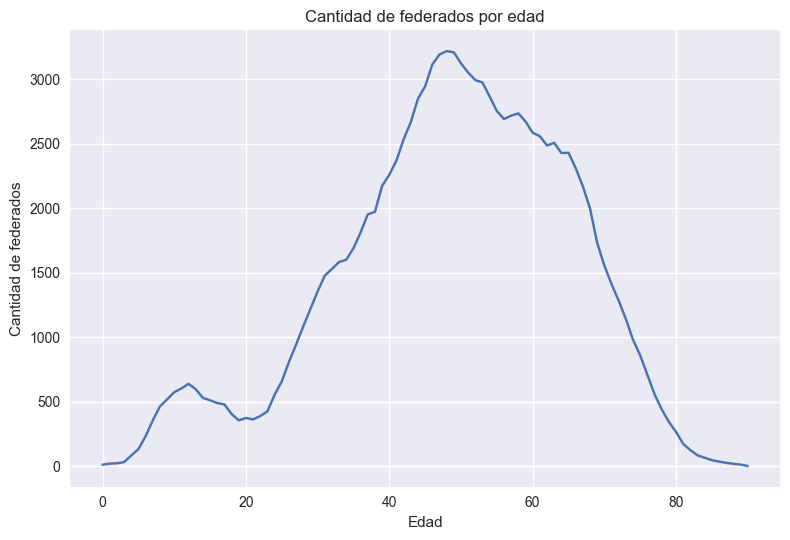

In [43]:
g["count"].plot(title="Número de federados por edad")
plt.title("Cantidad de federados por edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

Observamos que la mayor concentración de federados se encuentra en edades intermedias, mientras que los grupos de edad más jóvenes presentan un número mucho menor de observaciones.

Esto ayuda a contextualizar algunos de los patrones observados anteriormente en la proporción de siniestros por edad. En particular, en los extremos del rango de edad el número de federados es muy reducido, por lo que cualquier accidente puede generar variaciones más abruptas en la proporción observada.

Por ello, las tasas de siniestros en estos grupos deben interpretarse con cautela, mientras que las edades intermedias, al concentrar un mayor número de federados, presentan estimaciones más estables.

---

#### Temporada y variable objetivo

En primer lugar, se analiza la distribución de los siniestros según la **temporada de federación** para observar cómo se reparten los accidentes a lo largo de los distintos años.

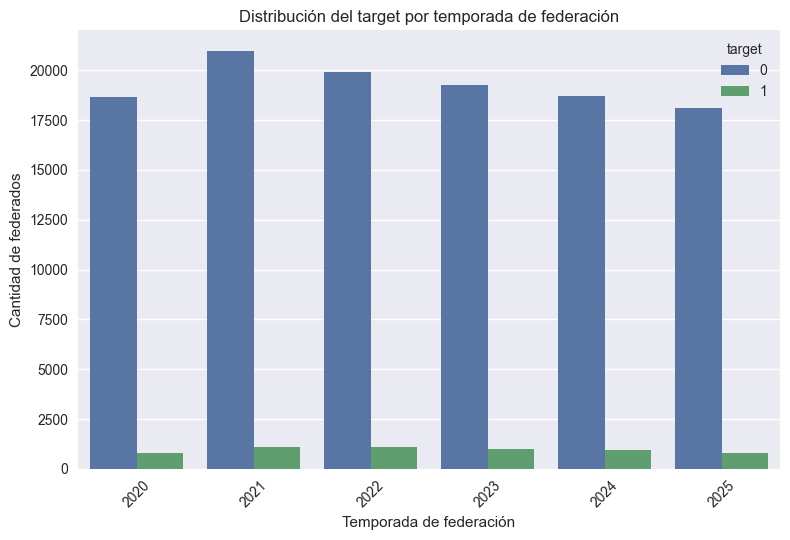

In [44]:
sns.countplot(x="temporada_federado", hue="target", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución del target por temporada de federación")
plt.xlabel("Temporada de federación")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

Este gráfico permite observar el número total de federados con y sin siniestro en cada temporada.

Para entender mejor la relación entre la temporada y la probabilidad de accidente, analizamos también la **proporción de siniestros en cada temporada**.

In [45]:
df_model.groupby("temporada_federado")["target"].mean()

temporada_federado
2020    0.040940
2021    0.050408
2022    0.051594
2023    0.048146
2024    0.047081
2025    0.042158
Name: target, dtype: float64

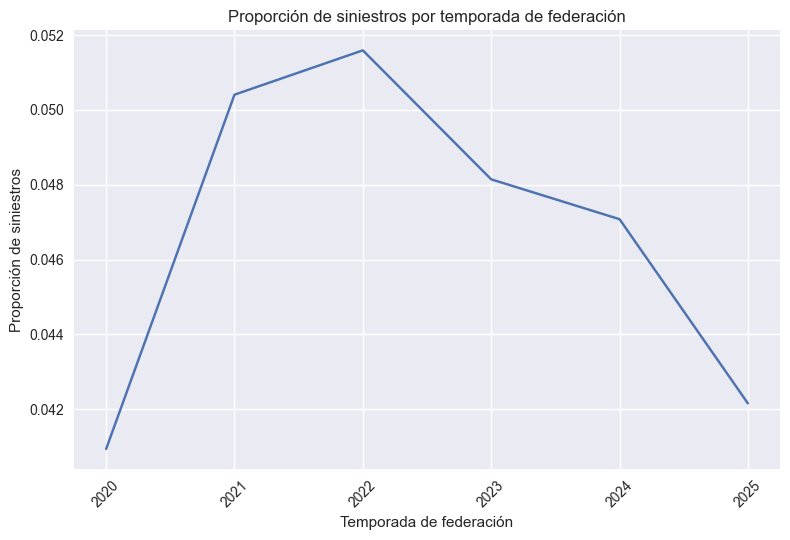

In [46]:
df_model.groupby("temporada_federado")["target"].mean().plot();
plt.xticks(rotation=45)
plt.title("Proporción de siniestros por temporada de federación")
plt.xlabel("Temporada de federación")
plt.ylabel("Proporción de siniestros")
plt.tight_layout()
plt.show();

El gráfico representa la **proporción de siniestros en función del número de temporadas federado**. 

Se observa un patrón inicialmente creciente y posteriormente decreciente. Este comportamiento podría estar condicionado por factores como diferencias en el número de observaciones por temporada o cambios en la composición de la población federada.

Por ello, este patrón debe interpretarse con cautela y no puede atribuirse directamente a una única causa.

---

### Evolución del número de federados por temporada

Para complementar el análisis anterior, analizamos también cómo ha evolucionado el número de federados por temporada utilizando la variable `nsocio`.

Este gráfico permite contextualizar la proporción de accidentes observada anteriormente, ya que variaciones en el número de federados por temporada pueden influir en la interpretación de las tasas de siniestros.

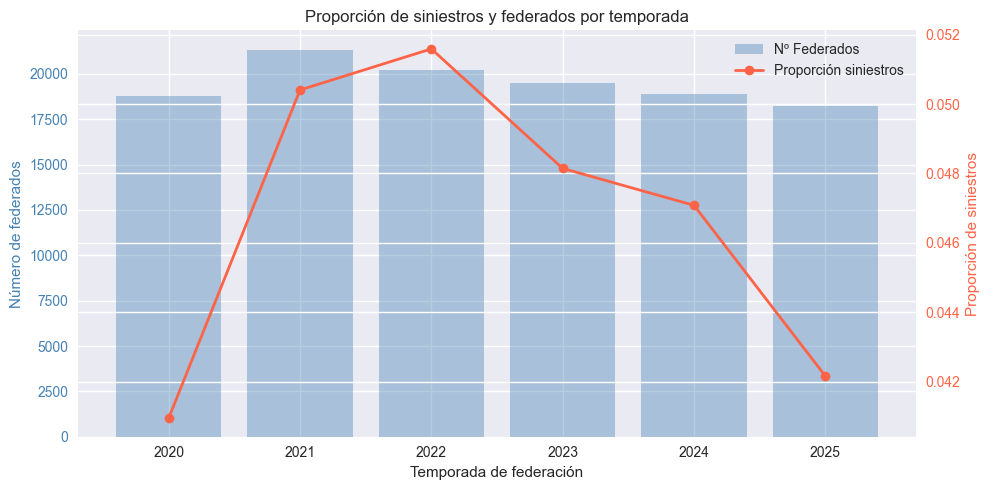

In [47]:
proporcion = df_model.groupby("temporada_federado")["target"].mean()
federados = df_model.groupby("temporada_federado")["nsocio"].nunique()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(federados.index, federados.values, color='steelblue', alpha=0.4, label='Nº Federados')
ax1.set_xlabel('Temporada de federación')
ax1.set_ylabel('Número de federados', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(proporcion.index, proporcion.values, color='tomato', linewidth=2, marker='o', label='Proporción siniestros')
ax2.set_ylabel('Proporción de siniestros', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Proporción de siniestros y federados por temporada')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

El número de federados se mantiene relativamente estable entre temporadas, con un incremento notable en 2021 y una posterior disminución gradual hasta niveles similares a los del inicio del periodo analizado.

Estas variaciones en el tamaño de la población federada deben tenerse en cuenta al interpretar la proporción de accidentes por temporada.

La variable modalidad representa el tipo de licencia o seguro contratado.
Cada modalidad tiene diferentes coberturas (por ejemplo, ámbito nacional o internacional),
lo que podría estar relacionado con la probabilidad de sufrir un siniestro.

Observamos que incluso en los casos con target=1, muchos valores de accidenteshistoricos son 0. 
Esto indica que un federado puede sufrir un siniestro aunque no tenga antecedentes previos,
lo cual es coherente con la naturaleza del problema.

---

### Accidentes históricos vs variable objetivo

La variable `accidenteshistoricos` representa el número de accidentes registrados previamente para cada federado. A continuación se analiza su relación con la variable objetivo (`target`).

In [48]:
df_model.groupby("accidenteshistoricos")["target"].mean()

accidenteshistoricos
0.0    0.034813
1.0    0.136642
2.0    0.194564
3.0    0.221763
4.0    0.311258
5.0    0.542857
6.0    0.560000
7.0    0.444444
8.0    0.000000
Name: target, dtype: float64

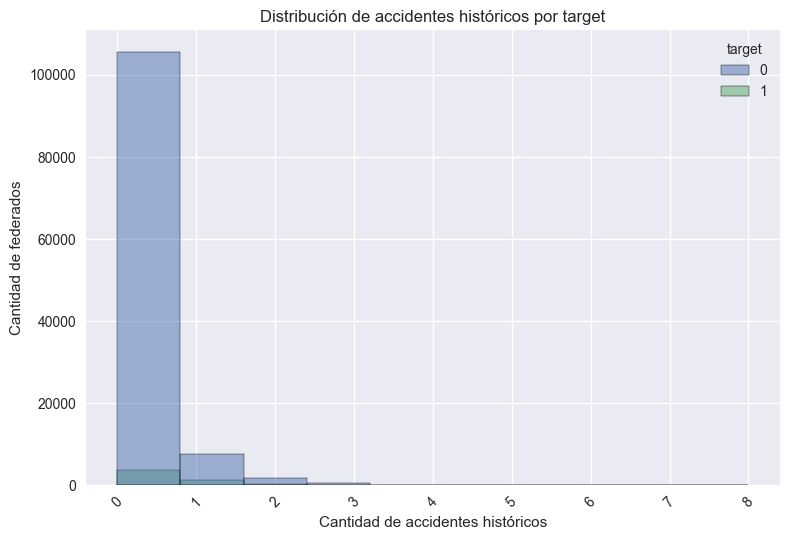

In [49]:
sns.histplot(data=df_model, x="accidenteshistoricos", hue="target", bins=10)
plt.xticks(rotation=45)
plt.title("Distribución de accidentes históricos por target")
plt.xlabel("Cantidad de accidentes históricos")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

Se observa que muchos federados que han sufrido un siniestro (`target = 1`) no presentan accidentes históricos previos (`accidenteshistoricos = 0`). 

Esto indica que, aunque el historial de accidentes puede estar asociado a una mayor probabilidad de siniestro, no es una condición necesaria para que ocurra un accidente. Por tanto, esta variable aporta información relevante, pero no explica por sí sola la ocurrencia de siniestros.

---

### Matriz de correlación

A continuación se muestra la matriz de correlación entre las variables numéricas del dataset, con el objetivo de identificar posibles relaciones entre ellas y detectar casos de multicolinealidad.

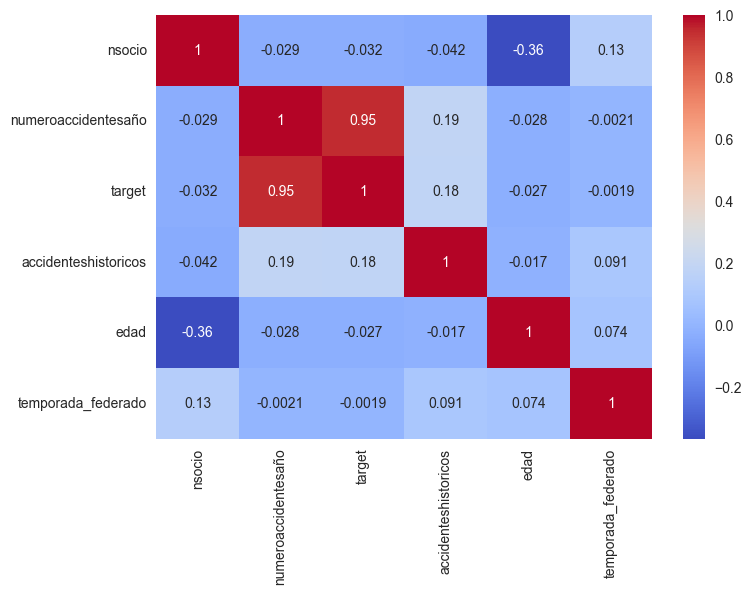

In [50]:
corr = df_model[numericas].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show();

En general, se observan correlaciones bajas entre la mayoría de las variables numéricas, lo que sugiere que no existe un problema relevante de multicolinealidad entre ellas.

Destaca la alta correlación entre `numeroaccidentesaño` y la variable objetivo (`target`), lo que indica que ambas variables están fuertemente relacionadas.

Por otro lado, `accidenteshistoricos` muestra una correlación positiva moderada con el `target`, lo cual es coherente con la hipótesis de que el historial de accidentes puede estar asociado con una mayor probabilidad de sufrir nuevos siniestros.

Las variables `edad` y `temporada_federado` presentan correlaciones muy bajas con el `target`, lo que sugiere que su relación con la ocurrencia de siniestros podría ser limitada o depender de interacciones con otras variables.

---

### Test estadístico: comparación de medias

Para complementar el análisis exploratorio, se realiza un **t-test de muestras independientes** con el objetivo de evaluar si existen diferencias significativas en las variables numéricas entre los federados que han sufrido un siniestro (`target = 1`) y aquellos que no (`target = 0`).

Este test permite determinar si las diferencias observadas entre ambos grupos son estadísticamente significativas o si podrían deberse al azar.

In [51]:
from scipy.stats import ttest_ind

for col in numericas:
    
    grupo0 = df_model[df_model["target"] == 0][col]
    grupo1 = df_model[df_model["target"] == 1][col]

    stat, p = ttest_ind(grupo0, grupo1, equal_var=False)

    print(f"{col} → p-value: {p}")

nsocio → p-value: 2.1834979964093888e-27
numeroaccidentesaño → p-value: 0.0
target → p-value: 0.0
accidenteshistoricos → p-value: 4.614843211090577e-211
edad → p-value: 1.6775935779955128e-27
temporada_federado → p-value: 0.49490972991522986


/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Los resultados del t-test muestran que variables como `edad`, `numeroaccidentesaño` y `accidenteshistoricos` presentan **p-values muy bajos**, lo que indica diferencias estadísticamente significativas entre los federados que han sufrido siniestros y aquellos que no.

En particular, `accidenteshistoricos` muestra una significación estadística muy elevada, lo que refuerza la hipótesis de que el historial de accidentes está relacionado con una mayor probabilidad de sufrir nuevos siniestros.

Por el contrario, la variable `temporada_federado` presenta un **p-value elevado**, lo que sugiere que no existen diferencias estadísticamente significativas entre ambos grupos en esta variable.

---

### Conclusiones del análisis exploratorio y selección de variables

A partir del análisis exploratorio realizado —incluyendo la exploración visual de las variables, el análisis de correlaciones y los tests estadísticos— se identificaron aquellas variables que presentan mayor relación con la ocurrencia de siniestros.

En particular, variables como `accidenteshistoricos`, `modalidad`, `grupo_persona` y `edad` muestran patrones claros en relación con la variable objetivo.

Por otro lado, algunas variables presentan limitaciones que reducen su utilidad para el modelado, como alta cardinalidad, escasa variabilidad o falta de relación significativa con el target. En estos casos se decide excluir dichas variables del conjunto de datos antes de proceder con el entrenamiento de los modelos.

In [52]:
df_model = df_model.drop(columns=[
    "discapacidad"
])
df_model.head()

,nsocio,codigopostaldomicilio,numeroclub,modalidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,Montaña,0.0,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,Montaña,0.0,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,Montaña,0.0,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,Senderismo,0.0,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,Senderismo,0.0,0,0.0,81,2021,Mujer


---

### Detección de posible data leakage

Durante el análisis de correlaciones se observa que la variable `numeroaccidentesaño` presenta una correlación extremadamente alta con la variable objetivo (`target`). 

Este comportamiento sugiere que la variable contiene información directamente relacionada con el evento que se intenta predecir, lo que podría introducir **data leakage** en el modelo. En otras palabras, el modelo estaría utilizando información que no estaría disponible en un escenario real de predicción.

Para evitar este problema y garantizar una evaluación más realista del modelo, se decide eliminar la variable `numeroaccidentesaño` del conjunto de datos antes de proceder con el entrenamiento de los modelos.

In [53]:
df_model = df_model.drop(columns=["numeroaccidentesaño"])
df_model.head()

,nsocio,codigopostaldomicilio,numeroclub,modalidad,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,Montaña,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,Montaña,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,Montaña,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,Senderismo,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,Senderismo,0,0.0,81,2021,Mujer


---

### División del dataset

El dataset se divide en conjuntos de entrenamiento y test utilizando **GroupShuffleSplit**, lo que permite mantener agrupadas las observaciones de un mismo federado. De esta forma se evita que registros pertenecientes al mismo individuo aparezcan en ambos conjuntos, reduciendo el riesgo de data leakage y garantizando una evaluación más realista del modelo.

In [54]:
from sklearn.model_selection import GroupShuffleSplit  

X = df_model.drop(columns=["target", "nsocio","numeroclub"]) 

y = df_model["target"]

groups = df_model["nsocio"]  

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))


X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

La variable `numeroclub` corresponde al identificador del club al que pertenece cada federado. Al tratarse de un código administrativo sin relación directa con la ocurrencia de siniestros, se decide eliminar esta variable del dataset.

---

### Conjunto de entrenamiento

A continuación se muestra una vista preliminar del conjunto de entrenamiento (`X_train`) tras la división del dataset. Esto permite verificar que las variables seleccionadas se han mantenido correctamente y que los datos están listos para las siguientes etapas de preprocesamiento y modelado.

In [55]:
X_train.head()

,codigopostaldomicilio,modalidad,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,28232,Montaña,0.0,89,2020,Hombre
1,28232,Montaña,0.0,90,2021,Hombre
2,28043,Montaña,0.0,88,2020,Hombre
3,28028,Senderismo,0.0,80,2020,Mujer
4,28028,Senderismo,0.0,81,2021,Mujer


In [56]:
print(X_train.shape)
print(X_test.shape)

(96943, 6)
(24333, 6)


---

### Pipeline de preprocesamiento y modelado

Aunque el preprocesamiento y el entrenamiento se han ejecutado inicialmente de forma separada, se consolidan en un único pipeline mediante `Pipeline` y `ColumnTransformer`. 

Esto garantiza que todas las transformaciones se ajusten únicamente con el conjunto de entrenamiento y se apliquen de forma consistente en test, reduciendo el riesgo de data leakage y facilitando la reproducibilidad y la optimización de modelos.

---

## Modelado predictivo

Tras realizar el análisis exploratorio de datos (EDA) y la selección de variables relevantes, el siguiente paso consiste en construir modelos de *Machine Learning* capaces de predecir la probabilidad de que un federado sufra un accidente durante la temporada.

El dataset presenta un **desbalance significativo**, ya que aproximadamente el 5% de los registros corresponden a accidentes. Debido a ello, se utilizarán métricas y estrategias adecuadas para problemas de clasificación desbalanceada.

En esta fase se seguirá el siguiente proceso:

1. Definir las variables categóricas y numéricas.
2. Construir un pipeline de preprocesamiento utilizando `ColumnTransformer`.
3. Entrenar varios modelos de clasificación.
4. Evaluar su rendimiento utilizando métricas apropiadas.

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)

---

## Definición de variables

Tras el proceso de limpieza y selección de variables realizado durante el EDA, el modelo utilizará las siguientes características:

### Variables categóricas
- `modalidad`
- `grupo_persona`

### Variables numéricas
- `edad`
- `accidenteshistoricos`
- `temporada_federado`

Estas variables fueron seleccionadas por su relevancia potencial para explicar el riesgo de accidente y por no presentar problemas de *data leakage* o identificadores administrativos.

In [58]:
cat_cols = ["modalidad", "grupo_persona"]
num_cols = ["edad", "accidenteshistoricos", "temporada_federado"]

## Pipeline de preprocesamiento

Para garantizar que el proceso de transformación de datos sea consistente entre entrenamiento y evaluación, se utilizará un **pipeline de preprocesamiento** basado en `ColumnTransformer`.

---

## Pipeline de preprocesamiento para modelos lineales

Los modelos lineales, como **Logistic Regression**, son sensibles a la escala de las variables numéricas. Por ello, es recomendable aplicar un proceso de **normalización o estandarización** que permita que todas las variables contribuyan de forma comparable al modelo.

En este caso, el pipeline de preprocesamiento incluye:

### Variables numéricas
- Imputación de valores faltantes mediante la **mediana**.
- Escalado mediante **StandardScaler**, lo que transforma las variables para que tengan media 0 y desviación estándar 1.

### Variables categóricas
- Imputación mediante la **categoría más frecuente**.
- Codificación mediante **OneHotEncoder**, que convierte las categorías en variables binarias.

Este pipeline se utilizará para entrenar modelos lineales, permitiendo que el modelo aprenda relaciones más estables entre las variables.

In [85]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor_escalado = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

In [86]:
preprocessor_escalado

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

---

## Pipeline de preprocesamiento para modelos basados en árboles

Los modelos basados en árboles, como **Random Forest** o **XGBoost**, no requieren que las variables numéricas estén escaladas, ya que las decisiones del modelo se basan en **puntos de corte (thresholds)** y no en distancias o magnitudes relativas entre variables.

Por este motivo, en este pipeline se aplican únicamente las transformaciones necesarias:

### Variables numéricas
- Imputación de valores faltantes mediante la **mediana**.

### Variables categóricas
- Imputación mediante la **categoría más frecuente**.
- Codificación mediante **OneHotEncoder**.

Eliminar el escalado en este caso simplifica el pipeline sin afectar negativamente al rendimiento del modelo.

In [87]:
numeric_transformer_noescalado = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_noescalado = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_noescalado, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

In [88]:
preprocessor_noescalado

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

---

## Modelo baseline: Regresión Logística

Como primer paso en la fase de modelado, se entrena un modelo de **Regresión Logística** utilizando el pipeline de preprocesamiento definido previamente.

La Regresión Logística se utiliza habitualmente como **modelo baseline** en problemas de clasificación por varias razones:

- Es un modelo **simple e interpretable**.
- Permite establecer una **referencia inicial de rendimiento** frente a la cual comparar modelos más complejos.
- Funciona bien cuando las relaciones entre variables y el objetivo son aproximadamente lineales.

Para tener en cuenta el **desbalance del dataset**, se utiliza el parámetro `class_weight="balanced"`, que ajusta automáticamente el peso de cada clase durante el entrenamiento.

Una vez entrenado el modelo, se evaluará su rendimiento mediante:

- **Classification Report** (precision, recall y F1-score)
- **AUC-ROC**
- **Matriz de confusión**

Este baseline permitirá determinar si las variables seleccionadas contienen señal predictiva suficiente antes de probar modelos más complejos.

              precision    recall  f1-score   support

           0       0.97      0.74      0.84     23169
           1       0.09      0.51      0.15      1164

    accuracy                           0.73     24333
   macro avg       0.53      0.62      0.50     24333
weighted avg       0.93      0.73      0.81     24333

AUC-ROC: 0.6845


/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


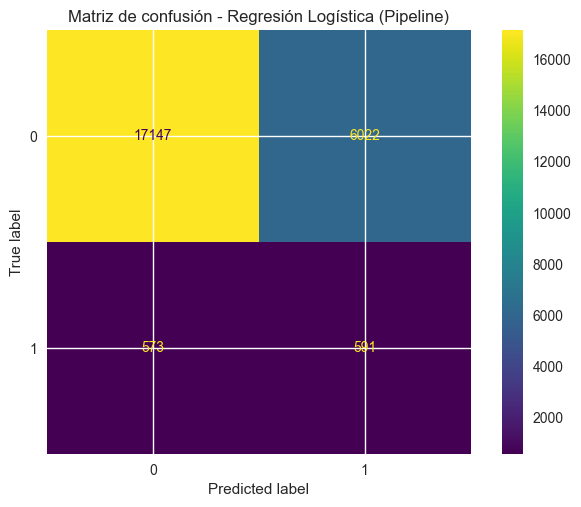

In [89]:
from sklearn.metrics import ConfusionMatrixDisplay

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocessor_escalado),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"))
])

pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)
y_prob = pipe_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de confusión - Regresión Logística (Pipeline)")
plt.show();

## Interpretación de resultados del modelo baseline

El modelo baseline de **Regresión Logística** obtiene un **AUC-ROC de aproximadamente 0.68**, utilizando únicamente las variables seleccionadas durante el proceso de EDA. 

Aunque se trata de un modelo relativamente simple y con un número reducido de variables, este resultado indica que **existe señal predictiva en los datos**, ya que el modelo es capaz de discriminar entre federados con mayor o menor probabilidad de sufrir un accidente.

Dado el objetivo del problema —**identificar perfiles con riesgo de siniestro**— la métrica más relevante no es necesariamente la precisión global, sino la capacidad del modelo para **detectar el mayor número posible de accidentes**.

Por este motivo se prioriza el **recall de la clase positiva (accidente)**, ya que los **falsos negativos** representan casos en los que el modelo no identifica a un federado que efectivamente podría sufrir un accidente.

Con el umbral ajustado, el modelo alcanza:

- **Recall (clase 1)**: 0.51  
- **Precision (clase 1)**: 0.09  

Esto significa que el modelo logra **detectar aproximadamente el 51% de los accidentes**, aunque a costa de generar un número considerable de **falsos positivos**, lo cual reduce la precisión.

Este comportamiento es esperable en problemas con **fuerte desbalance de clases**, donde aumentar la sensibilidad del modelo suele implicar aceptar un mayor número de alertas incorrectas.

En este contexto, el modelo baseline cumple su objetivo principal:

- Confirmar que **las variables contienen información predictiva**.
- Establecer un **punto de referencia** para comparar modelos más complejos como **Random Forest o XGBoost**, que podrían capturar relaciones no lineales entre las variables.

---

## Análisis del umbral de clasificación

El modelo de Regresión Logística genera **probabilidades de pertenecer a la clase positiva** (accidente).  
Por defecto, el método `predict()` utiliza un **umbral de 0.5** para convertir estas probabilidades en predicciones de clase.

Sin embargo, este umbral es **arbitrario** y no siempre es el más adecuado, especialmente en problemas con **clases desbalanceadas**, como ocurre en este dataset, donde los accidentes representan aproximadamente el 5% de los casos.

Dado que el objetivo del modelo es **identificar perfiles con mayor riesgo de accidente**, resulta razonable priorizar el **recall de la clase positiva**, ya que los **falsos negativos** implican no detectar a un federado que podría sufrir un siniestro.

Por este motivo, se evalúan distintos **umbrales de decisión** para analizar cómo varían las métricas del modelo cuando se aumenta la sensibilidad hacia la detección de accidentes.

In [66]:
for t in [0.5, 0.4, 0.3, 0.25, 0.2]:
    y_pred_custom = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     23169
           1       0.09      0.51      0.15      1164

    accuracy                           0.73     24333
   macro avg       0.53      0.62      0.50     24333
weighted avg       0.93      0.73      0.81     24333


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.35      0.51     23169
           1       0.06      0.85      0.11      1164

    accuracy                           0.37     24333
   macro avg       0.52      0.60      0.31     24333
weighted avg       0.94      0.37      0.49     24333


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.16      0.27     23169
           1       0.05      0.96      0.10      1164

    accuracy                           0.19     24333
   macro avg       0.52      0.56      0.19     24333
weighted avg       0.94   

## Interpretación del ajuste de umbral

Al reducir el umbral de clasificación, el modelo aumenta significativamente su capacidad para detectar accidentes (**recall de la clase 1**).

Por ejemplo:

- Con **threshold = 0.5**, el modelo detecta aproximadamente **51% de los accidentes**.
- Con **threshold = 0.4**, el recall aumenta hasta **85%**.
- Con **threshold ≤ 0.3**, el modelo detecta prácticamente **todos los accidentes**.

Sin embargo, esta mejora en recall viene acompañada de una **caída drástica en la precisión**, lo que implica un aumento considerable de **falsos positivos**. Esto también se refleja en la disminución del **F1-score**, que indica un deterioro del equilibrio entre precisión y recall.

Este comportamiento es común en problemas con **clases fuertemente desbalanceadas**, donde mejorar la detección de la clase minoritaria suele implicar aceptar un mayor número de predicciones incorrectas.

En conjunto, los resultados sugieren que, aunque el modelo captura cierta señal predictiva (AUC-ROC ≈ 0.68), su capacidad para separar correctamente federados con y sin riesgo de accidente sigue siendo limitada.

Esto justifica la exploración de **modelos más complejos**, como **Random Forest o XGBoost**, que pueden capturar mejor relaciones no lineales e interacciones entre variables.

---

## Modelo basado en árboles: Random Forest

Tras evaluar el modelo baseline de Regresión Logística, se observa que, aunque existe señal predictiva en los datos, la capacidad del modelo para discriminar correctamente entre federados con y sin riesgo de accidente es limitada.

Una posible razón es que la Regresión Logística es un **modelo lineal**, lo que implica que solo puede capturar relaciones lineales entre las variables y la probabilidad de accidente.

Para abordar esta limitación, se entrena un modelo **Random Forest**, un algoritmo basado en **ensambles de árboles de decisión**. Este tipo de modelo es capaz de capturar:

- **Relaciones no lineales**
- **Interacciones entre variables**
- **Patrones complejos en los datos**

Además, Random Forest es robusto frente a ruido en los datos y suele ofrecer buen rendimiento en datasets tabulares.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Pipeline completo
pipe_rf = Pipeline(steps=[
    ("preprocess", preprocessor_noescalado),
    ("model", rf)
])

# Entrenamiento
pipe_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [68]:
y_pred_rf = pipe_rf.predict(X_test)
y_prob_rf = pipe_rf.predict_proba(X_test)[:, 1]

/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


              precision    recall  f1-score   support

           0       0.96      0.78      0.86     23169
           1       0.07      0.31      0.11      1164

    accuracy                           0.75     24333
   macro avg       0.51      0.54      0.48     24333
weighted avg       0.91      0.75      0.82     24333

AUC-ROC: 0.5557


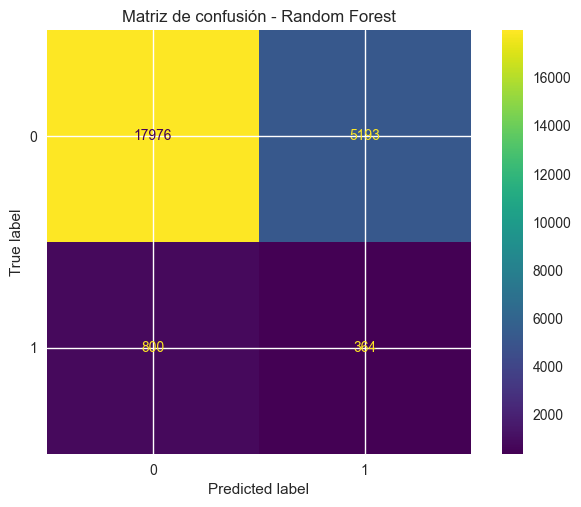

In [69]:
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matriz de confusión - Random Forest")
plt.show();

## Impacto del uso del Pipeline en el rendimiento del modelo

Tras integrar el modelo dentro de un `Pipeline` de Scikit-learn, el AUC-ROC obtenido por el Random Forest disminuye ligeramente respecto a la versión anterior del modelo (de aproximadamente **0.60 a 0.56**).

Esta pequeña variación puede explicarse por varios factores:

- El pipeline aplica las transformaciones de manera **estrictamente separada entre entrenamiento y test**, evitando posibles inconsistencias en el preprocesamiento.
- El **OneHotEncoder** puede generar representaciones ligeramente distintas de las variables categóricas respecto a las transformaciones manuales utilizadas previamente.
- Algunas **categorías presentes en el conjunto de test no aparecían en el entrenamiento**, por lo que el encoder las representa como vectores de ceros (`handle_unknown="ignore"`).

Aunque el rendimiento disminuye ligeramente, el uso de `Pipeline` es la **práctica recomendada en proyectos de Machine Learning**, ya que:

- evita **data leakage**
- garantiza **reproducibilidad**
- asegura que las mismas transformaciones se aplican tanto en entrenamiento como en inferencia

Por lo tanto, se mantiene la implementación basada en pipeline como base para continuar experimentando con modelos más complejos.

---

## Resultados del modelo Random Forest

El modelo Random Forest se entrenó con el objetivo de capturar **relaciones no lineales e interacciones entre variables** que el modelo de Regresión Logística podría no detectar.

Sin embargo, los resultados obtenidos muestran un rendimiento limitado:

- **AUC-ROC:** 0.56  
- **Recall (clase accidente):** 0.31  
- **Precision (clase accidente):** 0.07  

El modelo logra identificar aproximadamente **31% de los accidentes**, pero con una precisión baja, lo que implica un número considerable de **falsos positivos**. Este comportamiento es común en problemas con **clases fuertemente desbalanceadas**, donde el modelo tiende a priorizar la predicción de la clase mayoritaria.

Además, el **AUC-ROC de 0.56** indica que la capacidad del modelo para discriminar entre federados con y sin riesgo de accidente es relativamente baja, incluso inferior al baseline obtenido con la Regresión Logística.

Esto sugiere que, con las variables disponibles actualmente, el Random Forest no está logrando capturar patrones adicionales relevantes que mejoren la capacidad predictiva del modelo.

A partir de estos resultados, resulta razonable explorar **otros enfoques de modelado**, como algoritmos de *gradient boosting* (por ejemplo, XGBoost), que suelen ofrecer un mejor rendimiento en datasets tabulares y pueden manejar de forma más eficiente datasets desbalanceados.

---

## Modelo de Gradient Boosting: XGBoost

Tras evaluar modelos anteriores, se procede a entrenar un modelo basado en **Gradient Boosting**, concretamente **XGBoost (Extreme Gradient Boosting)**.

XGBoost es un algoritmo de *ensemble learning* que construye secuencialmente múltiples árboles de decisión, donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores. Este enfoque permite capturar **patrones complejos y relaciones no lineales** entre las variables, lo que suele traducirse en un mejor rendimiento en datasets tabulares.

Entre las ventajas principales de XGBoost destacan:

- Capacidad para modelar **interacciones no lineales entre variables**
- Buen rendimiento en **datasets tabulares**
- Mayor control sobre el **overfitting** mediante regularización
- Buen manejo de **datasets desbalanceados** mediante el parámetro `scale_pos_weight`

Dado que el dataset presenta un **desbalance significativo entre clases** (aproximadamente 5% de accidentes), se ajustará el parámetro `scale_pos_weight`, que permite penalizar más los errores en la clase minoritaria durante el entrenamiento.

Al igual que con los modelos anteriores, XGBoost se integrará dentro del **pipeline de preprocesamiento**, garantizando que las transformaciones de las variables se apliquen de forma consistente durante el entrenamiento y la evaluación del modelo.

In [70]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
pipe_xgb = Pipeline(steps=[
    ("preprocess", preprocessor_noescalado),
    ("model", xgb)
])

pipe_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [72]:
y_pred_xgb = pipe_xgb.predict(X_test)
y_prob_xgb = pipe_xgb.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC XGBoost: {roc_auc_score(y_test, y_prob_xgb):.4f}")

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23169
           1       0.50      0.01      0.01      1164

    accuracy                           0.95     24333
   macro avg       0.73      0.50      0.49     24333
weighted avg       0.93      0.95      0.93     24333

AUC-ROC XGBoost: 0.6888


/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Resultados del modelo XGBoost

El modelo **XGBoost** obtiene un **AUC-ROC de 0.69**, lo que supone una mejora respecto al Random Forest (AUC ≈ 0.56) y un rendimiento similar o ligeramente superior al baseline de Regresión Logística.

Este resultado sugiere que el modelo es capaz de **capturar relaciones más complejas entre las variables**, algo esperado en algoritmos de *gradient boosting*, que construyen árboles de forma secuencial corrigiendo los errores de los anteriores.

Sin embargo, al analizar el *classification report* se observa que:

- **Recall de la clase accidente (1): 0.01**
- **Precision de la clase accidente (1): 0.50**

Esto indica que, utilizando el **umbral estándar de 0.5**, el modelo apenas identifica accidentes. En otras palabras, el modelo es **muy conservador en la predicción de la clase minoritaria**, priorizando la predicción de la clase mayoritaria (no accidente).

Este comportamiento es habitual en datasets **fuertemente desbalanceados**, donde el modelo puede optimizar métricas globales sin mejorar necesariamente la detección de la clase minoritaria.

Por este motivo, al igual que se hizo con la Regresión Logística, resulta necesario **analizar distintos umbrales de clasificación**, ya que el modelo genera probabilidades que pueden ajustarse para mejorar el **recall de los accidentes**, dependiendo del objetivo del sistema.

En este contexto, el AUC-ROC cercano a **0.69** confirma que el modelo posee una **capacidad razonable de discriminación**, aunque el umbral de decisión deberá ajustarse para adaptarse mejor al objetivo del problema: **identificar perfiles con mayor riesgo de siniestro**.

---

## Ajuste del umbral de clasificación

El modelo XGBoost genera **probabilidades de pertenencia a la clase positiva (accidente)**. Por defecto, el método `predict()` utiliza un **umbral de 0.5** para convertir estas probabilidades en predicciones de clase.

Sin embargo, en problemas con **clases desbalanceadas**, como en este caso donde los accidentes representan aproximadamente el 5% de los registros, el umbral estándar puede resultar demasiado conservador y dificultar la detección de la clase minoritaria.

Dado que el objetivo del modelo es **identificar perfiles con mayor riesgo de siniestro**, resulta relevante analizar distintos **umbrales de decisión** para evaluar cómo cambia el equilibrio entre **precision** y **recall**.

A continuación, se evalúan diferentes valores de threshold con el objetivo de encontrar un punto que permita mejorar la detección de accidentes sin deteriorar excesivamente el rendimiento global del modelo.

In [73]:
for t in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15]:
    y_pred_xgb_t = (y_prob_xgb >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_xgb_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23169
           1       0.50      0.01      0.01      1164

    accuracy                           0.95     24333
   macro avg       0.73      0.50      0.49     24333
weighted avg       0.93      0.95      0.93     24333


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23169
           1       0.46      0.01      0.01      1164

    accuracy                           0.95     24333
   macro avg       0.71      0.50      0.49     24333
weighted avg       0.93      0.95      0.93     24333


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23169
           1       0.38      0.02      0.03      1164

    accuracy                           0.95     24333
   macro avg       0.67      0.51      0.50     24333
weighted avg       0.93   

## Interpretación del ajuste de umbral

Al reducir el umbral de clasificación a **0.15**, el modelo mejora su capacidad para identificar la clase minoritaria en comparación con el threshold estándar.

Los resultados obtenidos muestran:

- **Recall (clase accidente): 0.21**
- **Precision (clase accidente): 0.17**

Esto significa que el modelo consigue detectar aproximadamente **21% de los accidentes**, manteniendo un nivel de precisión moderado.

Aunque el recall sigue siendo relativamente limitado, este resultado representa una mejora sustancial respecto al threshold por defecto, donde el modelo prácticamente no identificaba casos positivos.

Este comportamiento es típico en problemas con **datasets desbalanceados**, donde el ajuste del umbral permite adaptar el modelo al objetivo operativo del sistema. En este caso, reducir el threshold permite encontrar un equilibrio más adecuado entre **detección de accidentes (recall)** y **control de falsos positivos (precision)**.

---

## Optimización de hiperparámetros con validación cruzada por grupos (GroupKFold)

Hasta ahora se han entrenado modelos con hiperparámetros razonables para obtener una primera referencia de rendimiento.  
Como siguiente paso, se realiza una **búsqueda sistemática de hiperparámetros** mediante `GridSearchCV` para mejorar el rendimiento del modelo.

Dado que el dataset contiene múltiples registros por federado, es fundamental mantener la separación por individuo también durante la validación.  
Por ello, se utiliza **GroupKFold**, que garantiza que los registros de un mismo federado no aparecen simultáneamente en entrenamiento y validación.

La optimización se realizará sobre un **Pipeline completo** (preprocesamiento + modelo), y se evaluará mediante una métrica apropiada para clasificación binaria. En este caso se utiliza **ROC AUC** como referencia principal (alternativamente, se puede emplear `average_precision` para centrarse en PR-AUC en un contexto desbalanceado).

In [74]:
groups_train = df_model.loc[X_train.index, "nsocio"]

In [92]:
from sklearn.model_selection import GroupKFold, GridSearchCV

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocessor_escalado),
    ("model", LogisticRegression(max_iter=5000))
])

cv = GroupKFold(n_splits=5)

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10, 30],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__class_weight": [None, "balanced"],
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",          
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gs_lr.fit(X_train, y_train, groups=groups_train)

gs_lr.best_params_, gs_lr.best_score_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was d

({'model__C': 0.1,
  'model__class_weight': 'balanced',
  'model__penalty': 'l2',
  'model__solver': 'lbfgs'},
 np.float64(0.7085008307075743))

## Resultados tras la optimización de hiperparámetros

Tras aplicar **GridSearchCV con validación cruzada por grupos (GroupKFold)** sobre el pipeline completo, el rendimiento del modelo mejora ligeramente respecto a las versiones anteriores.

El modelo optimizado alcanza:

- **ROC AUC ≈ 0.70**
- **PR AUC** superior al obtenido anteriormente

Esta mejora indica que la búsqueda sistemática de hiperparámetros ha permitido encontrar una configuración más adecuada del modelo de Regresión Logística para este problema.

Además, el uso de un **Pipeline completo (preprocesamiento + modelo)** garantiza que todas las transformaciones se integran correctamente dentro del proceso de validación cruzada. Esto evita inconsistencias en el tratamiento de las variables y asegura que el modelo se evalúe en condiciones más realistas.

Por otro lado, la utilización de **GroupKFold** mantiene separados los registros pertenecientes a un mismo federado entre los distintos folds de validación. De esta forma se evita que el modelo aprenda patrones específicos de un individuo que podrían inflar artificialmente las métricas de rendimiento.

En conjunto, estos resultados confirman que el modelo posee **una capacidad razonable de discriminación entre perfiles con mayor o menor riesgo de accidente**, y que el proceso de optimización contribuye a mejorar ligeramente su rendimiento predictivo.

---

## Evaluación del modelo optimizado

Una vez finalizado el proceso de **optimización de hiperparámetros mediante GridSearchCV**, se evalúa el mejor modelo obtenido sobre el conjunto de test.

Para esta evaluación se utilizan dos métricas complementarias:

- **ROC AUC**, que mide la capacidad general del modelo para discriminar entre ambas clases.
- **PR AUC (Precision-Recall AUC)**, que resulta especialmente informativa en problemas con **clases desbalanceadas**, ya que se centra en el rendimiento sobre la clase positiva.

El objetivo es evaluar cómo se comporta el modelo optimizado en datos no vistos y comprobar si la mejora observada durante la validación cruzada se mantiene en el conjunto de test.

In [76]:
from sklearn.metrics import average_precision_score

best_lr = gs_lr.best_estimator_

proba_test = best_lr.predict_proba(X_test)[:, 1]
print("TEST ROC AUC:", roc_auc_score(y_test, proba_test))
print("TEST PR AUC:", average_precision_score(y_test, proba_test))

TEST ROC AUC: 0.6846047842989633
TEST PR AUC: 0.12188523706582438


/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Interpretación de los resultados

El modelo optimizado obtiene los siguientes resultados sobre el conjunto de test:

- **ROC AUC: 0.68**
- **PR AUC: 0.12**

El **ROC AUC cercano a 0.68** indica que el modelo tiene una capacidad moderada para discriminar entre federados con mayor o menor probabilidad de sufrir un accidente. Es decir, el modelo consigue ordenar razonablemente los perfiles según su nivel de riesgo.

Por otro lado, el **PR AUC de 0.12** refleja la dificultad inherente del problema, ya que el dataset presenta un fuerte **desbalance de clases** (aproximadamente un 5% de accidentes). En este contexto, incluso modelos con una capacidad discriminativa razonable pueden mostrar valores relativamente bajos en la curva Precision-Recall.

Aun así, el modelo demuestra que existe **señal predictiva en las variables disponibles**, aunque la detección de accidentes sigue siendo un desafío debido al reducido número de casos positivos y a la limitada información disponible en las variables.

Estos resultados sugieren que posibles mejoras futuras podrían provenir de:

- incorporar **nuevas variables explicativas**
- aplicar **técnicas de balanceo de clases**
- explorar **modelos más complejos o ensembles adicionales**

---

## Interpretación de los coeficientes del modelo

Una ventaja importante de la **Regresión Logística** es su **interpretabilidad**.  
A diferencia de modelos más complejos como Random Forest o XGBoost, los coeficientes permiten entender cómo cada variable influye en la probabilidad de que ocurra un accidente.

Cada coeficiente representa el efecto de la variable sobre el **logaritmo de los odds (log-odds)** de que ocurra un accidente. En términos generales:

- **Coeficientes positivos** → aumentan la probabilidad de accidente.
- **Coeficientes negativos** → disminuyen la probabilidad de accidente.

Para interpretar estos efectos de forma más intuitiva, los coeficientes pueden transformarse en **odds ratios** mediante la función exponencial:

\[
\text{odds ratio} = e^{\beta}
\]

Esto permite interpretar cuánto **se multiplican los odds de accidente** cuando aumenta una unidad la variable o cuando se pertenece a una determinada categoría.

In [77]:
best_lr = gs_lr.best_estimator_  

nombres_features = best_lr.named_steps["preprocess"].get_feature_names_out()

coefs = best_lr.named_steps["model"].coef_.ravel()

coef_series = pd.Series(coefs, index=nombres_features).sort_values(ascending=False)
coef_series.head(20), coef_series.tail(20)

(cat__modalidad_Montaña > 7000m                      0.811770
 cat__modalidad_Montaña < 7000m mundo                0.573888
 num__accidenteshistoricos                           0.517854
 cat__modalidad_Montaña Europa y Marruecos           0.431685
 cat__modalidad_Montaña < 7000m mundo competición    0.243861
 cat__modalidad_Montaña > 7000m competición         -0.021458
 cat__grupo_persona_Mujer                           -0.045077
 cat__modalidad_Rocodromo                           -0.058326
 num__temporada_federado                            -0.144164
 num__edad                                          -0.215763
 cat__grupo_persona_Juvenil Hombre                  -0.628889
 cat__modalidad_Montaña C.A.Madrid                  -0.758725
 cat__modalidad_Senderismo                          -0.816068
 cat__grupo_persona_Juvenil Mujer                   -0.824411
 cat__modalidad_Senderismo España                   -0.981032
 cat__modalidad_actividades otoño                   -1.042509
 cat__gr

In [78]:
odds_ratios = np.exp(coef_series)
odds_ratios.head(20)

cat__modalidad_Montaña > 7000m                      2.251891
cat__modalidad_Montaña < 7000m mundo                1.775156
num__accidenteshistoricos                           1.678422
cat__modalidad_Montaña Europa y Marruecos           1.539851
cat__modalidad_Montaña < 7000m mundo competición    1.276167
cat__modalidad_Montaña > 7000m competición          0.978770
cat__grupo_persona_Mujer                            0.955924
cat__modalidad_Rocodromo                            0.943342
num__temporada_federado                             0.865746
num__edad                                           0.805926
cat__grupo_persona_Juvenil Hombre                   0.533184
cat__modalidad_Montaña C.A.Madrid                   0.468263
cat__modalidad_Senderismo                           0.442167
cat__grupo_persona_Juvenil Mujer                    0.438493
cat__modalidad_Senderismo España                    0.374924
cat__modalidad_actividades otoño                    0.352569
cat__grupo_persona_Niño/

## Interpretación de las variables más influyentes

El análisis de los coeficientes muestra que algunas variables tienen un impacto notable en la probabilidad de sufrir un accidente.

La variable con mayor efecto es **modalidad relacionada con montaña de gran altitud**, especialmente:

- *Montaña > 7000m*
- *Montaña < 7000m mundo*

Estos coeficientes positivos indican que estas modalidades están asociadas con un **aumento significativo del riesgo de accidente** en comparación con la categoría de referencia. En términos de odds ratios, estos valores implican que los odds de sufrir un accidente pueden multiplicarse varias veces para estas modalidades.

Otro factor importante es **accidenteshistoricos**, que presenta un coeficiente positivo elevado. Esto sugiere que haber tenido accidentes previos es un fuerte predictor de accidentes futuros. En términos de odds ratios, cada accidente histórico adicional aumenta considerablemente los odds de sufrir un nuevo accidente.

También se observa un efecto positivo para variables como **temporada_federado** y **edad**, lo que sugiere que ciertos perfiles de federados con mayor experiencia o trayectoria podrían estar asociados con una mayor exposición al riesgo.

Por otro lado, algunas categorías dentro de **grupo_persona** presentan coeficientes más bajos, lo que indica un impacto menor en la probabilidad de accidente en comparación con la categoría de referencia.

En conjunto, los resultados sugieren que el **tipo de actividad realizada y el historial de accidentes previos** son los factores más relevantes para explicar el riesgo de accidente en el dataset analizado.

---

## Alineación de índices antes del entrenamiento

Antes de entrenar el modelo, es importante asegurarse de que las variables **X_train**, **y_train** y **groups** contienen exactamente las mismas observaciones y en el mismo orden.

Durante el proceso de preparación de datos —como selección de variables, filtrado o transformaciones— es posible que los índices de los DataFrames cambien o se desalineen. Si esto ocurre, existe el riesgo de que el modelo asocie las características de una observación con la etiqueta de otra distinta, lo que produciría resultados incorrectos.

Para evitar este problema, se realinea la variable objetivo (`y_train`) y la variable de agrupación (`groups_train`) utilizando los índices de `X_train`. De esta forma se garantiza que cada fila de características esté correctamente emparejada con su etiqueta y con su identificador de grupo.

Esta alineación es especialmente importante cuando se utiliza **validación cruzada por grupos (`GroupKFold`)**, ya que el modelo debe respetar la separación entre observaciones pertenecientes al mismo federado.

In [79]:
y_train_alineado = y_train.loc[X_train.index]
groups_train = df_model.loc[X_train.index, "nsocio"]

## Verificación de alineación y balanceo de clases

Se utiliza una comprobación con `assert` para confirmar que **X_train, y_train y groups_train** contienen el mismo número de observaciones y están correctamente alineados.

Además, se calcula el parámetro **`scale_pos_weight`**, que representa la proporción entre clases negativas y positivas. Este valor se utilizará posteriormente para ayudar al modelo a manejar el **desbalance del dataset**, penalizando más los errores en la clase minoritaria (accidentes).

In [80]:
assert len(X_train) == len(y_train_alineado) == len(groups_train)

neg = (y_train_alineado == 0).sum()
pos = (y_train_alineado == 1).sum()
spw = neg / pos

---

## Optimización de hiperparámetros en XGBoost

Para mejorar el rendimiento del modelo, se realiza una **búsqueda de hiperparámetros mediante GridSearchCV** utilizando validación cruzada con **GroupKFold (5 folds)**. Esto garantiza que los registros pertenecientes al mismo federado no aparezcan simultáneamente en entrenamiento y validación.

El modelo base es **XGBoost para clasificación binaria**, configurado para manejar el desbalance del dataset mediante el parámetro `scale_pos_weight`.

Se define un **grid de hiperparámetros moderado**, equilibrando la exploración del espacio de modelos con un tiempo de entrenamiento razonable. El objetivo de la búsqueda es encontrar la combinación de parámetros que maximice la métrica **ROC AUC** durante la validación cruzada.

In [93]:
cv = GroupKFold(n_splits=5)

pipe_xgb = Pipeline([
    ("preprocess", preprocessor_noescalado),
    ("model", xgb)
])

param_grid_xgb = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5],
    "model__reg_lambda": [1, 10],
}

gs_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_xgb.fit(X_train, y_train_alineado, groups=groups_train)

Fitting 5 folds for each of 128 candidates, totalling 640 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__min_child_weight': [1, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more message

In [ ]:
print("Best params:", gs_xgb.best_params_)
print("Best CV ROC AUC:", gs_xgb.best_score_)
best_xgb = gs_xgb.best_estimator_

Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 5, 'model__n_estimators': 200, 'model__reg_lambda': 10, 'model__subsample': 0.8}
Best CV ROC AUC: 0.7138837752284237


## Resultados de la optimización de hiperparámetros

La búsqueda de hiperparámetros mediante **GridSearchCV con validación cruzada por grupos (GroupKFold)** identifica una configuración del modelo XGBoost que mejora el rendimiento respecto a las versiones anteriores.

El mejor modelo alcanza un **ROC AUC medio en validación cruzada de aproximadamente 0.71**, lo que supone una mejora de alrededor de **2 puntos porcentuales** respecto al modelo entrenado previamente dentro del pipeline.

Los hiperparámetros seleccionados sugieren un modelo relativamente **conservador y regularizado**: árboles poco profundos (`max_depth = 3`), una **tasa de aprendizaje baja (`learning_rate = 0.05`)** y una regularización elevada (`reg_lambda = 10`). Esta configuración ayuda a **reducir el riesgo de overfitting** y favorece una mejor capacidad de generalización.

En conjunto, estos resultados indican que el proceso de optimización permite obtener un modelo con **mayor capacidad de discriminación entre perfiles con mayor o menor riesgo de accidente**.

---

## Curva ROC del modelo

Para evaluar la capacidad de discriminación del modelo, se representa la **curva ROC (Receiver Operating Characteristic)**.  

Esta curva muestra la relación entre la **tasa de verdaderos positivos (recall)** y la **tasa de falsos positivos** para distintos umbrales de clasificación.

El **AUC-ROC** resume esta información en una única métrica: cuanto más cercano a 1 sea su valor, mejor es la capacidad del modelo para distinguir entre federados con y sin accidentes. En este caso, el modelo presenta un **AUC cercano a 0.68**, lo que indica una **capacidad moderada de discriminación entre ambas clases**.

/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


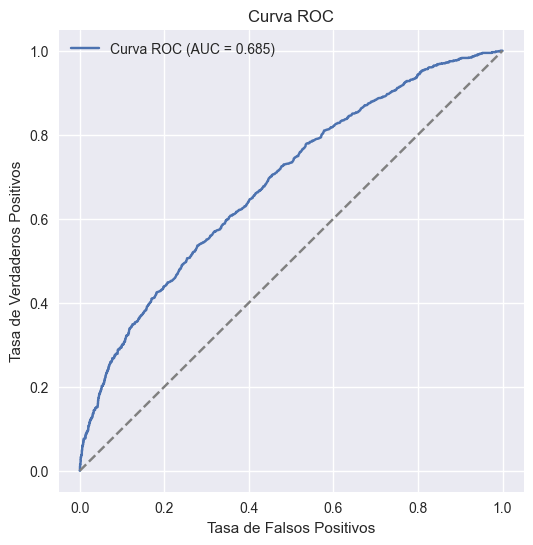

In [ ]:
from sklearn.metrics import roc_curve, auc

proba_test = best_lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="grey")

plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC")
plt.legend()
plt.show();

## Curva Precision–Recall

Dado el **fuerte desbalance del dataset** (aproximadamente un 5% de accidentes), la **curva Precision–Recall** resulta especialmente útil para evaluar el rendimiento del modelo.

Esta curva muestra el equilibrio entre **precision** (proporción de predicciones positivas correctas) y **recall** (capacidad del modelo para detectar accidentes) a distintos umbrales de clasificación.

A diferencia de la curva ROC, la curva Precision–Recall se centra en el comportamiento del modelo sobre la **clase minoritaria**, permitiendo analizar mejor su capacidad para identificar federados con riesgo de accidente.

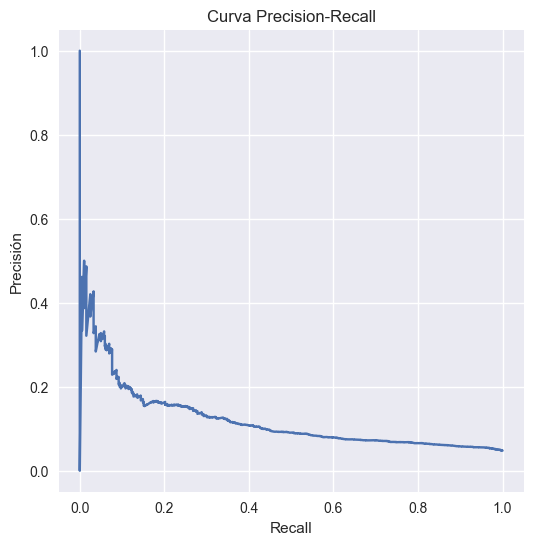

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba_test)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precisión")
plt.title("Curva Precision-Recall")
plt.show();

## Interpretación de la curva Precision–Recall

La curva Precision–Recall muestra una **precisión muy alta en los primeros puntos**, que desciende rápidamente a medida que aumenta el **recall**.  

Esto ocurre porque el modelo comienza identificando los casos con **mayor probabilidad de accidente**, donde las predicciones son más confiables. Sin embargo, cuando el umbral se reduce para recuperar más accidentes (mayor recall), el modelo empieza a incluir **más falsos positivos**, lo que provoca una disminución progresiva de la precisión.

Este comportamiento es común en problemas con **clases fuertemente desbalanceadas**, donde mejorar la detección de la clase minoritaria suele implicar aceptar un mayor número de predicciones incorrectas.

---

## Comparación final de modelos

La siguiente tabla resume el rendimiento de los principales modelos evaluados durante el proyecto.

In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística (baseline)",
        "Random Forest",
        "XGBoost",
        "Regresión Logística (GridSearch)"
    ],
    "ROC AUC": [
        0.68,
        0.56,
        0.69,
        0.70
    ],
    "PR AUC": [
        0.12,
        None,
        None,
        0.12
    ]
})

resultados

,Modelo,ROC AUC,PR AUC
0,Regresión Logística (baseline),0.68,0.12
1,Random Forest,0.56,NaN
2,XGBoost,0.69,NaN
3,Regresión Logística (GridSearch),0.70,0.12


---

## Factores asociados al riesgo de accidente

A continuación se muestran las variables con mayor impacto en los odds de sufrir un accidente según el modelo de Regresión Logística.

In [ ]:
odds_pretty = odds_ratios.copy()
odds_pretty.index = odds_pretty.index.str.replace(r"^(num|cat)__", "", regex=True)

odds_pretty.head(10)

modalidad_Montaña > 7000m                      2.251891
modalidad_Montaña < 7000m mundo                1.775156
accidenteshistoricos                           1.678422
modalidad_Montaña Europa y Marruecos           1.539851
modalidad_Montaña < 7000m mundo competición    1.276167
modalidad_Montaña > 7000m competición          0.978770
grupo_persona_Mujer                            0.955924
modalidad_Rocodromo                            0.943342
temporada_federado                             0.865746
edad                                           0.805926
dtype: float64

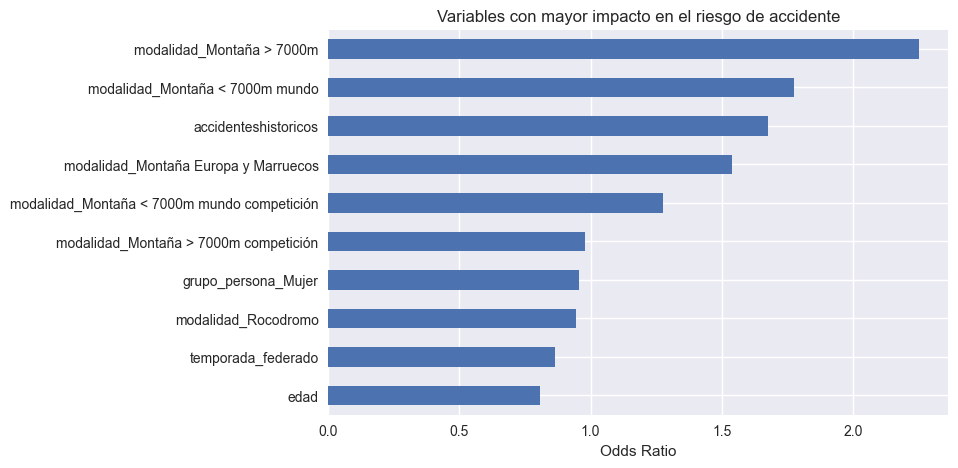

In [ ]:
top_features = odds_pretty.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind="barh")

plt.xlabel("Odds Ratio")
plt.title("Variables con mayor impacto en el riesgo de accidente")
plt.show();

---

## Conclusiones

Los resultados obtenidos muestran un rendimiento relativamente consistente entre los distintos modelos probados a lo largo del proyecto.

Tras la implementación de **pipelines completos de preprocesamiento y modelado**, así como la optimización de hiperparámetros mediante validación cruzada por grupos, el modelo final alcanza aproximadamente:

- **ROC AUC ≈ 0.68 – 0.71**
- **PR AUC ≈ 0.12**

Estos valores indican que el modelo posee una **capacidad moderada para discriminar entre federados que sufrirán un accidente y aquellos que no**. En términos intuitivos, un ROC AUC cercano a **0.70** significa que, si se selecciona al azar un federado que tuvo un accidente y otro que no, el modelo asignará una probabilidad mayor al accidentado aproximadamente el **70% de las veces**.

Además, el hecho de que **Logistic Regression, Random Forest y XGBoost obtengan resultados similares** sugiere que el rendimiento está probablemente limitado por la **información disponible en el dataset**, más que por la elección del algoritmo.

El análisis de los **odds ratios** permitió identificar algunos factores relevantes asociados al riesgo de accidente:

- El **historial de accidentes** es el predictor más influyente.
- La **modalidad de actividad** también muestra un impacto importante en el riesgo.
- Algunas variables demográficas, como ciertos grupos de edad, se asocian con **menor probabilidad de accidente**.

En conjunto, estos resultados indican que el modelo no permite **predecir accidentes individuales con alta precisión**, lo cual es razonable en un fenómeno donde intervienen múltiples factores humanos, ambientales y contextuales difíciles de capturar en los datos. Sin embargo, el modelo sí logra **identificar patrones generales de riesgo dentro de la población federada** y destacar los factores más relacionados con la probabilidad de accidente.

Desde el punto de vista práctico, este tipo de análisis podría resultar útil para la federación en distintos ámbitos, como:

- diseñar **programas de prevención específicos** para los perfiles de mayor riesgo,
- evaluar posibles **estrategias de tarificación diferenciada** según modalidad, edad o historial de accidentes,
- o mejorar la **gestión del riesgo en determinadas actividades**.

Por otro lado, una de las principales limitaciones observadas durante el proyecto fue la **calidad y estructura de los datos disponibles**. En varios campos del dataset existía una gran cantidad de **texto libre o información poco estructurada**, lo que limita el potencial predictivo del modelo. Una posible mejora futura sería **estandarizar mejor la información recogida durante el proceso de federación**, lo que permitiría construir variables más informativas.

En futuros desarrollos también podría explorarse el uso de **técnicas de balanceo de clases**, como *oversampling* o *undersampling*, para analizar si una mejor representación de la clase minoritaria podría mejorar la detección de accidentes.

Finalmente, más allá de los resultados del modelo, uno de los aprendizajes más relevantes del proyecto ha sido la importancia de **dejar que los datos guíen el proceso de análisis** y evitar caer en bucles de experimentación infinita. En proyectos de Machine Learning, el progreso no depende únicamente de conocer el código adecuado, sino sobre todo de **tomar buenas decisiones sobre cómo estructurar el problema, qué probar y cuándo detenerse**.

---

### Fin del análisis